# Data Exploration

In [25]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'no': '#e07b54', 'yes': '#378add'}


df_path = r"C:\Users\divye\Data_science_projects\5qaNUcRSLjHZ5anY\data\term-deposit-marketing-2020.csv"

df = pd.read_csv(df_path)

df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,no


In [26]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64

# EDA 

In [27]:
eda_df = df.copy()

print(eda_df['marital'].value_counts())
print(eda_df['education'].value_counts())
print(eda_df['default'].value_counts())


marital
married     24386
single      10889
divorced     4725
Name: count, dtype: int64
education
secondary    20993
tertiary     11206
primary       6270
unknown       1531
Name: count, dtype: int64
default
no     39191
yes      809
Name: count, dtype: int64


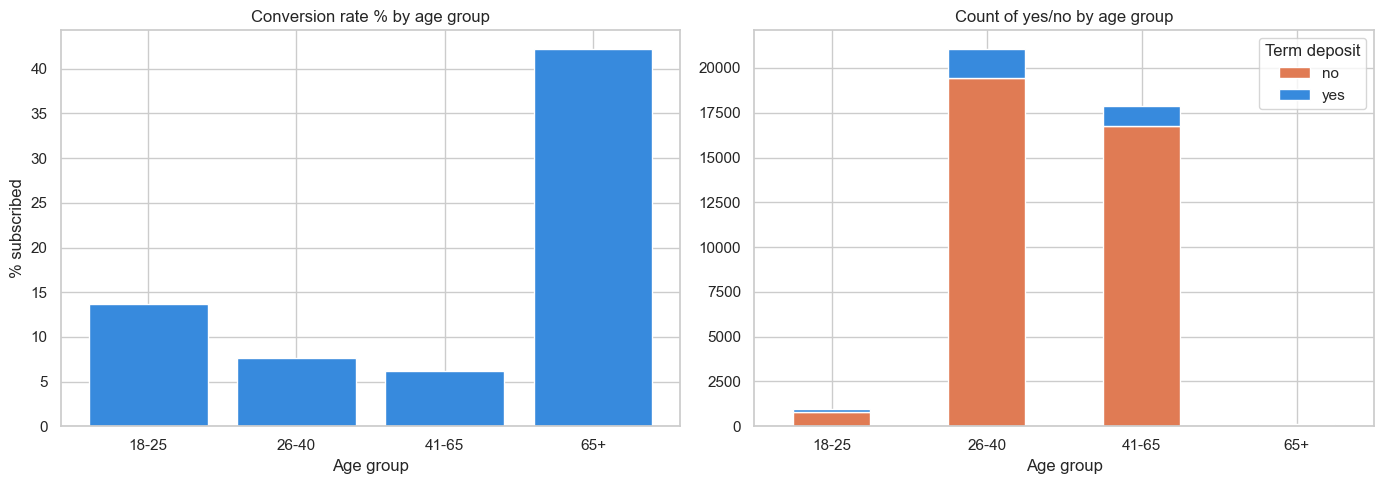

In [28]:
eda_df['age_group'] = pd.cut(eda_df['age'],
    bins=[17, 25, 40, 65, 100],
    labels=['18-25', '26-40', '41-65', '65+'])

# conversion rate per age group
age_conv = (eda_df.groupby('age_group', observed=True)['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reset_index(name='conversion_rate'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- plot 1: conversion rate bar ---
axes[0].bar(age_conv['age_group'].astype(str),
         age_conv['conversion_rate'],
         color='#378add', edgecolor='white')
axes[0].set_title('Conversion rate % by age group')
axes[0].set_xlabel('Age group')
axes[0].set_ylabel('% subscribed')

# --- plot 2: stacked count bar ---
age_counts = pd.crosstab(eda_df['age_group'], eda_df['y'])
age_counts.plot(kind='bar', stacked=True, ax=axes[1],
               color=['#e07b54', '#378add'], edgecolor='white')
axes[1].set_title('Count of yes/no by age group')
axes[1].set_xlabel('Age group')
axes[1].legend(title='Term deposit')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

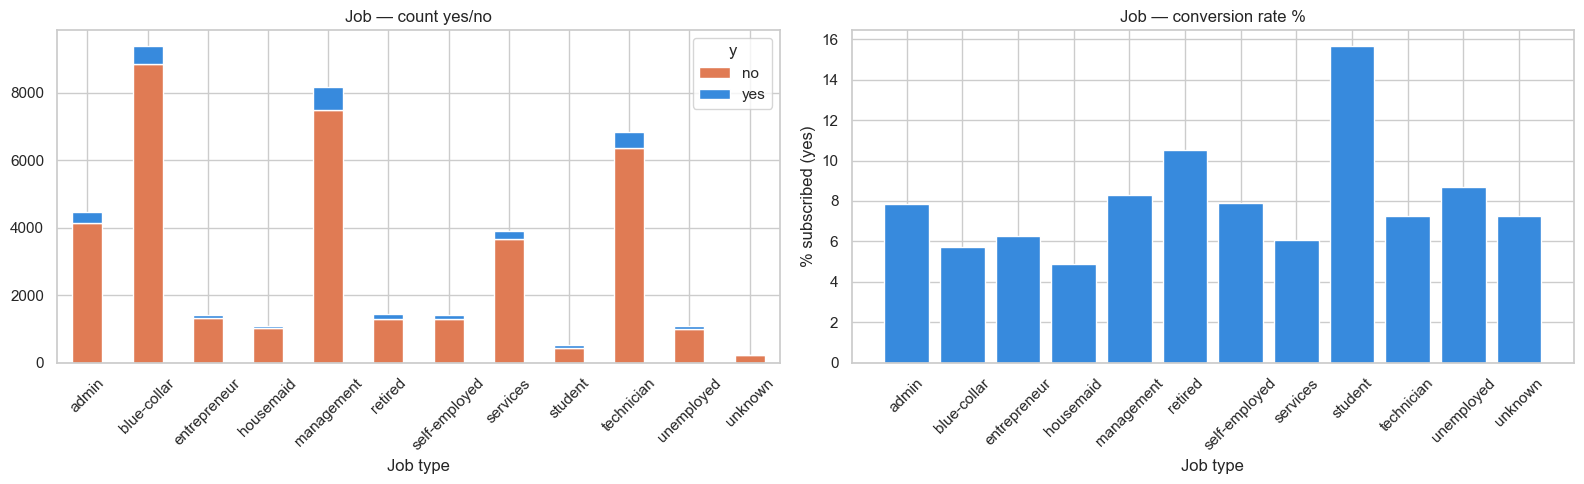

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

job_order = sorted(eda_df['job'].unique().tolist())

# Stacked count bar
job_counts = pd.crosstab(eda_df['job'], eda_df['y'])[
    ['no', 'yes']].reindex(job_order)
job_counts.plot(kind='bar', stacked=True, ax=axes[0],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
axes[0].set_title('Job — count yes/no')
axes[0].set_xlabel('Job type')
axes[0].tick_params(axis='x', rotation=45)

# Conversion rate bar
job_conv = (eda_df.groupby('job')['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reindex(job_order)
              .reset_index(name='pct_yes'))
axes[1].bar(job_conv['job'], job_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[1].set_title('Job — conversion rate %')
axes[1].set_xlabel('Job type')
axes[1].set_ylabel('% subscribed (yes)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

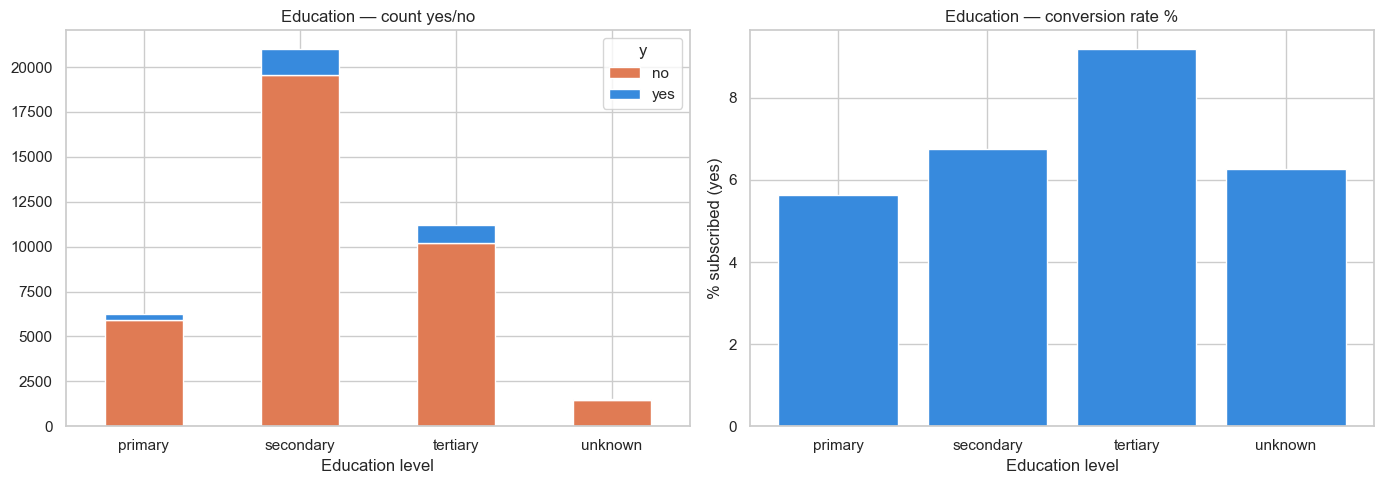

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

edu_order = ['primary', 'secondary', 'tertiary', 'unknown']

# Stacked count bar
edu_counts = pd.crosstab(eda_df['education'], eda_df['y'])[
    ['no', 'yes']].reindex(edu_order)
edu_counts.plot(kind='bar', stacked=True, ax=axes[0],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
axes[0].set_title('Education — count yes/no')
axes[0].set_xlabel('Education level')
axes[0].tick_params(axis='x', rotation=0)

# Conversion rate bar
edu_conv = (eda_df.groupby('education')['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reindex(edu_order)
              .reset_index(name='pct_yes'))
axes[1].bar(edu_conv['education'], edu_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[1].set_title('Education — conversion rate %')
axes[1].set_xlabel('Education level')
axes[1].set_ylabel('% subscribed (yes)')

plt.tight_layout()
plt.show()

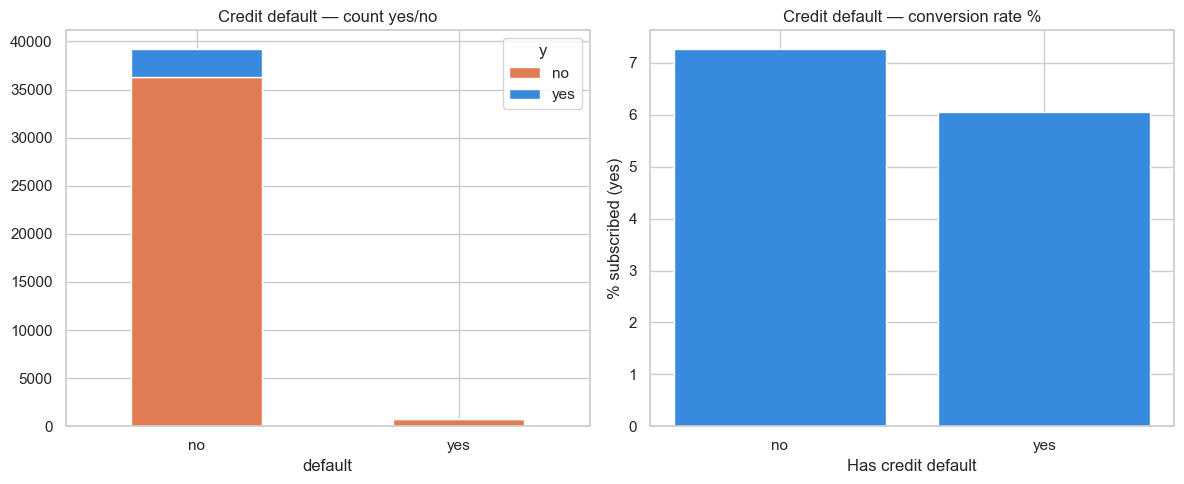

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def_counts = pd.crosstab(eda_df['default'], eda_df['y'])[['no', 'yes']]
def_counts.plot(kind='bar', stacked=True, ax=axes[0],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
axes[0].set_title('Credit default — count yes/no')
axes[0].tick_params(axis='x', rotation=0)

def_conv = (eda_df.groupby('default')['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reset_index(name='pct_yes'))
axes[1].bar(def_conv['default'], def_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[1].set_title('Credit default — conversion rate %')
axes[1].set_xlabel('Has credit default')
axes[1].set_ylabel('% subscribed (yes)')

plt.tight_layout()
plt.show()

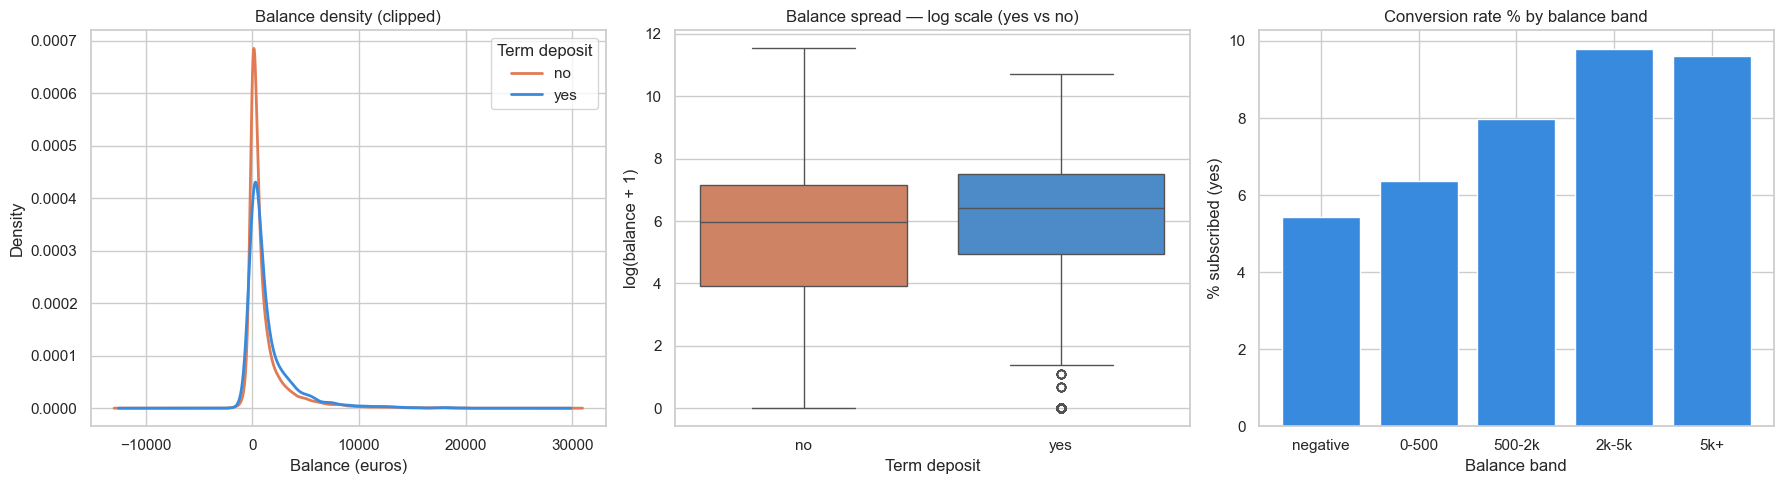

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KDE — clip extreme outliers for readability
bal_clip = eda_df[eda_df['balance'].between(-2000, 20000)]
for label, grp in bal_clip.groupby('y')['balance']:
    grp.plot.kde(ax=axes[0], label=label,
               linewidth=2, color=COLORS[label])
axes[0].set_title('Balance density (clipped)')
axes[0].set_xlabel('Balance (euros)')
axes[0].legend(title='Term deposit')

# shift balance so log works (balance can be 0 or negative)
eda_df['balance_log'] = np.log1p(eda_df['balance'].clip(lower=0))

sns.boxplot(data=eda_df, x='y', y='balance_log', ax=axes[1],
            order=['no', 'yes'], palette=COLORS)
axes[1].set_title('Balance spread — log scale (yes vs no)')
axes[1].set_xlabel('Term deposit')
axes[1].set_ylabel('log(balance + 1)')

# Balance bins conversion rate
eda_df['bal_group'] = pd.cut(eda_df['balance'],
    bins=[-10000, 0, 500, 2000, 5000, 100000],
    labels=['negative', '0-500', '500-2k', '2k-5k', '5k+'])
bal_conv = (eda_df.groupby('bal_group', observed=True)['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reset_index(name='pct_yes'))
axes[2].bar(bal_conv['bal_group'].astype(str),
         bal_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[2].set_title('Conversion rate % by balance band')
axes[2].set_xlabel('Balance band')
axes[2].set_ylabel('% subscribed (yes)')

plt.tight_layout()
plt.show()

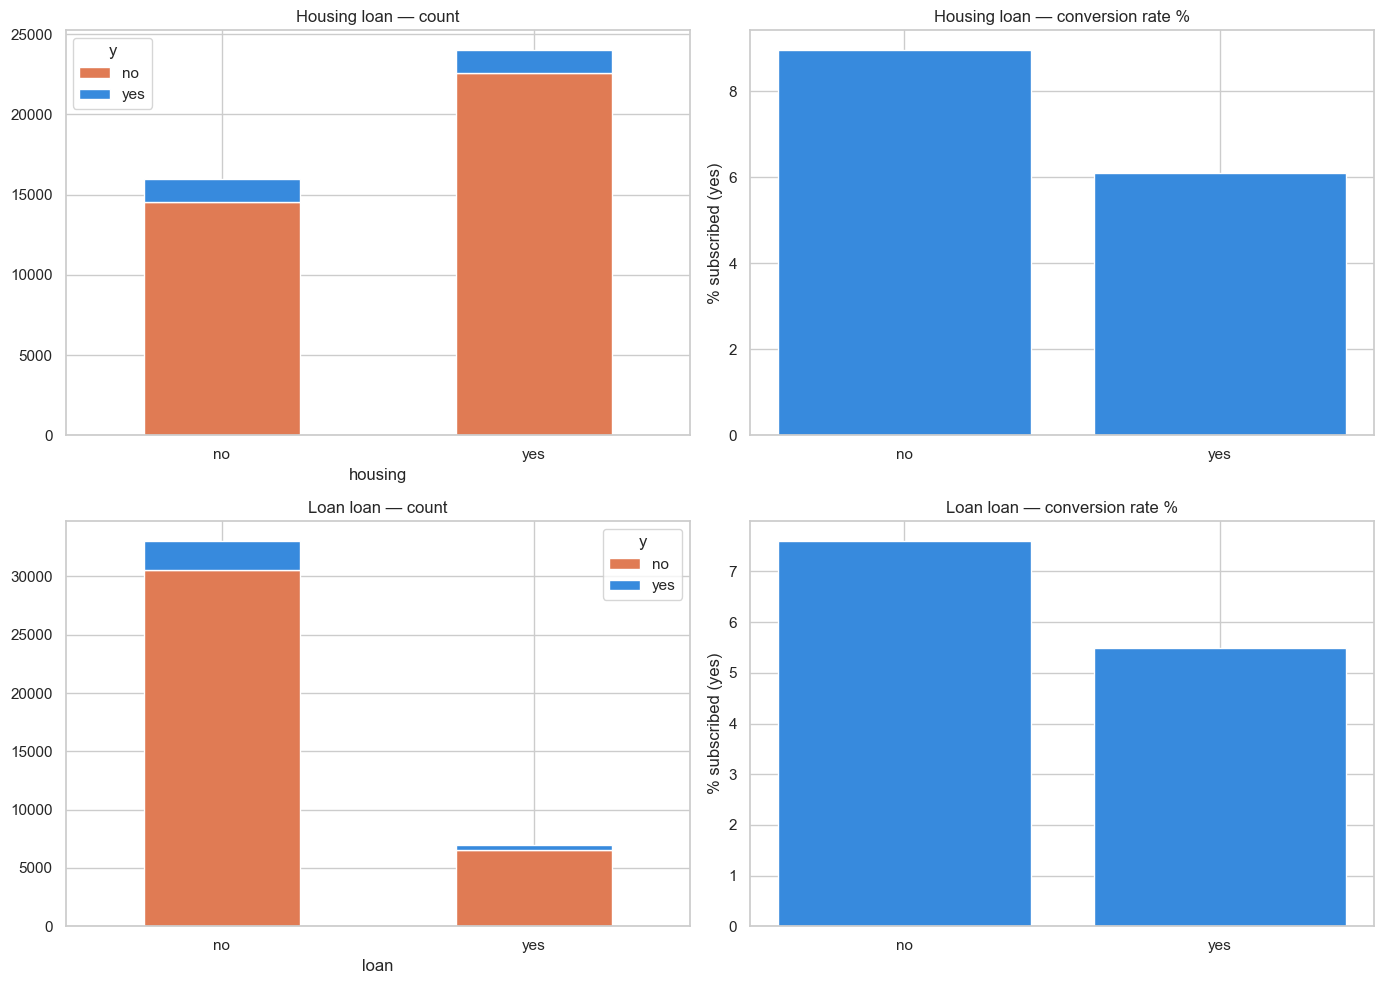

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(['housing', 'loan']):
    # stacked count
    counts = pd.crosstab(eda_df[col], eda_df['y'])[['no', 'yes']]
    counts.plot(kind='bar', stacked=True, ax=axes[i][0],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
    axes[i][0].set_title(f'{col.title()} loan — count')
    axes[i][0].tick_params(axis='x', rotation=0)

    # conversion rate
    conv = (eda_df.groupby(col)['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reset_index(name='pct_yes'))
    axes[i][1].bar(conv[col], conv['pct_yes'],
             color='#378add', edgecolor='white')
    axes[i][1].set_title(f'{col.title()} loan — conversion rate %')
    axes[i][1].set_ylabel('% subscribed (yes)')

plt.tight_layout()
plt.show()

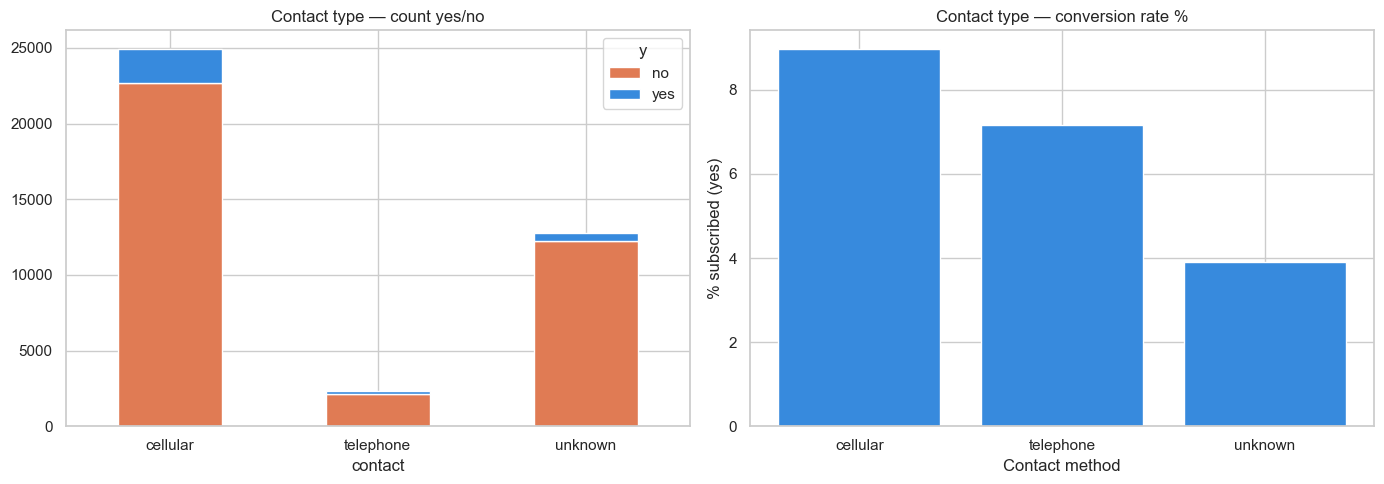

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct_counts = pd.crosstab(eda_df['contact'], eda_df['y'])[['no', 'yes']]
ct_counts.plot(kind='bar', stacked=True, ax=axes[0],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
axes[0].set_title('Contact type — count yes/no')
axes[0].tick_params(axis='x', rotation=0)

ct_conv = (eda_df.groupby('contact')['y']
             .apply(lambda x: (x == 'yes').mean() * 100)
             .reset_index(name='pct_yes'))
axes[1].bar(ct_conv['contact'], ct_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[1].set_title('Contact type — conversion rate %')
axes[1].set_xlabel('Contact method')
axes[1].set_ylabel('% subscribed (yes)')

plt.tight_layout()
plt.show()

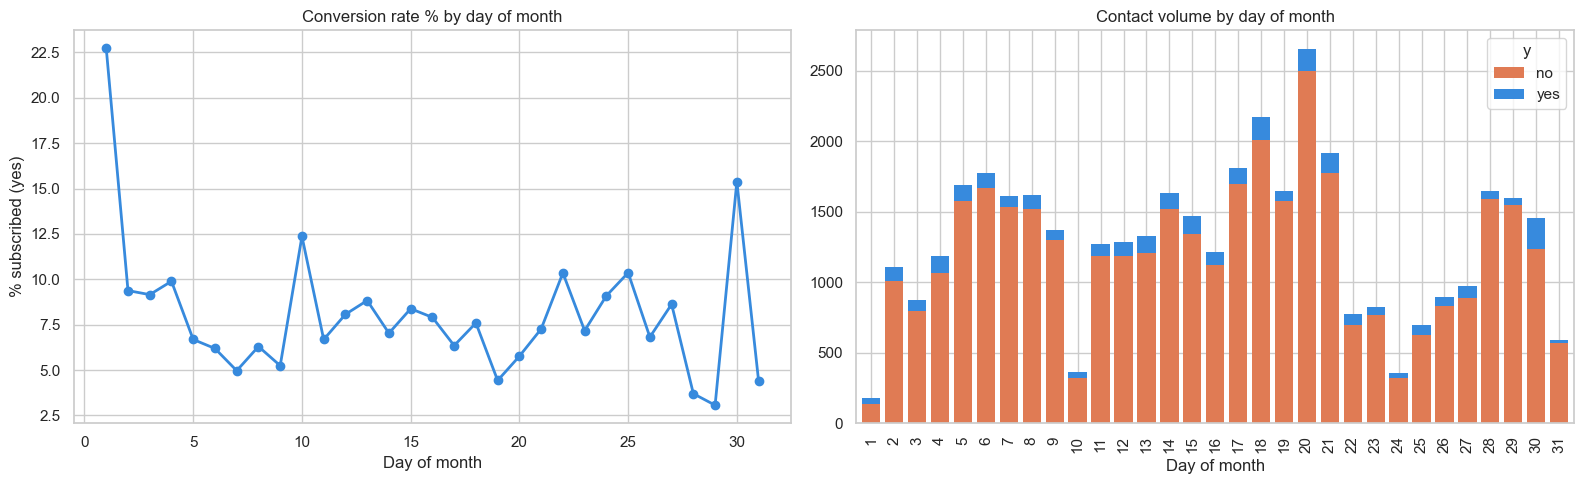

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Average conversion by day
day_conv = (eda_df.groupby('day')['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reset_index(name='pct_yes'))
axes[0].plot(day_conv['day'], day_conv['pct_yes'],
           marker='o', color='#378add', linewidth=2)
axes[0].set_title('Conversion rate % by day of month')
axes[0].set_xlabel('Day of month')
axes[0].set_ylabel('% subscribed (yes)')

# Volume of contacts per day
day_vol = eda_df.groupby(['day', 'y']).size().unstack(fill_value=0)
day_vol.plot(kind='bar', stacked=True, ax=axes[1],
            color=[COLORS['no'], COLORS['yes']],
            edgecolor='none', width=0.8)
axes[1].set_title('Contact volume by day of month')
axes[1].set_xlabel('Day of month')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

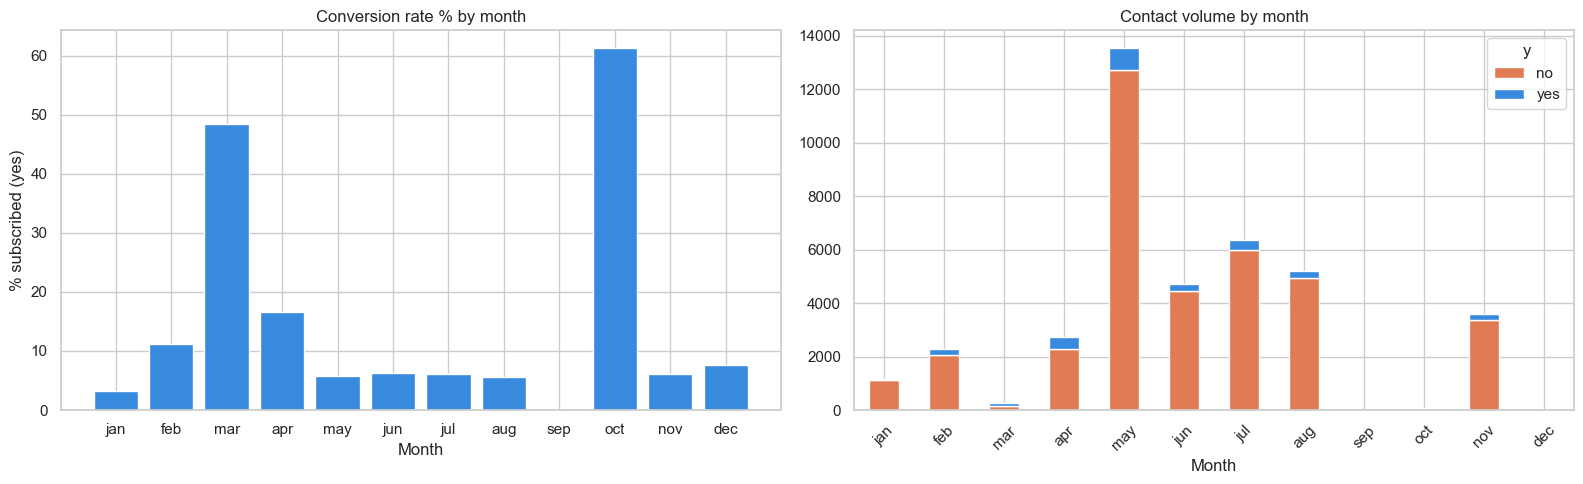

In [36]:
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

month_conv = (eda_df.groupby('month')['y']
                .apply(lambda x: (x == 'yes').mean() * 100)
                .reindex(month_order)
                .reset_index(name='pct_yes'))
axes[0].bar(month_conv['month'], month_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[0].set_title('Conversion rate % by month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('% subscribed (yes)')

month_vol = (eda_df.groupby(['month', 'y'])
               .size().unstack(fill_value=0)
               .reindex(month_order))
month_vol.plot(kind='bar', stacked=True, ax=axes[1],
              color=[COLORS['no'], COLORS['yes']],
              edgecolor='white')
axes[1].set_title('Contact volume by month')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

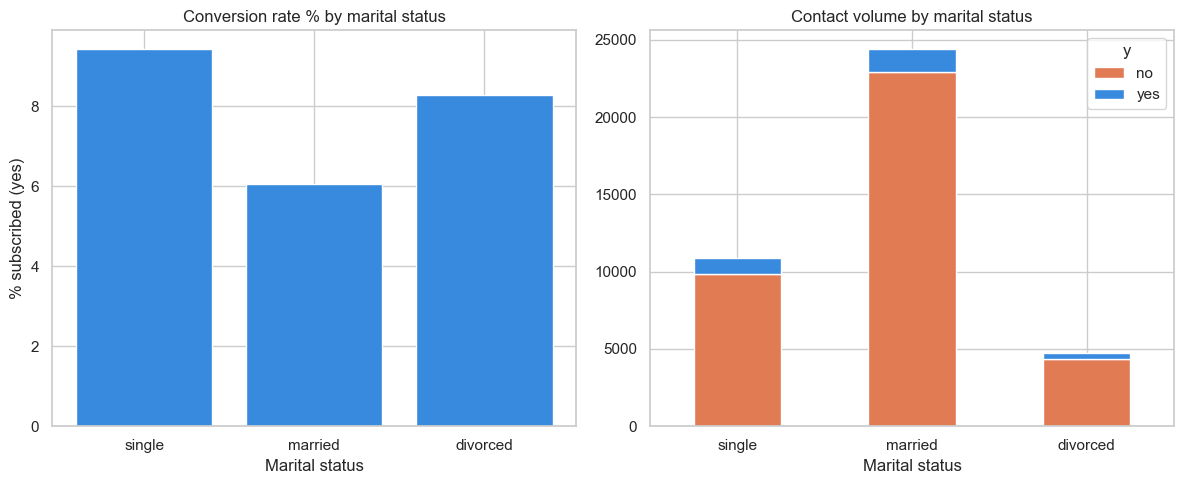

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

marital_order = ['single', 'married', 'divorced']

marital_conv = (eda_df.groupby('marital')['y']
                .apply(lambda x: (x == 'yes').mean() * 100)
                .reindex(marital_order)
                .reset_index(name='pct_yes'))
axes[0].bar(marital_conv['marital'], marital_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[0].set_title('Conversion rate % by marital status')
axes[0].set_xlabel('Marital status')
axes[0].set_ylabel('% subscribed (yes)')

marital_vol = (eda_df.groupby(['marital', 'y'])
               .size().unstack(fill_value=0)
               .reindex(marital_order))
marital_vol.plot(kind='bar', stacked=True, ax=axes[1],
              color=[COLORS['no'], COLORS['yes']],
              edgecolor='white')
axes[1].set_title('Contact volume by marital status')
axes[1].set_xlabel('Marital status')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

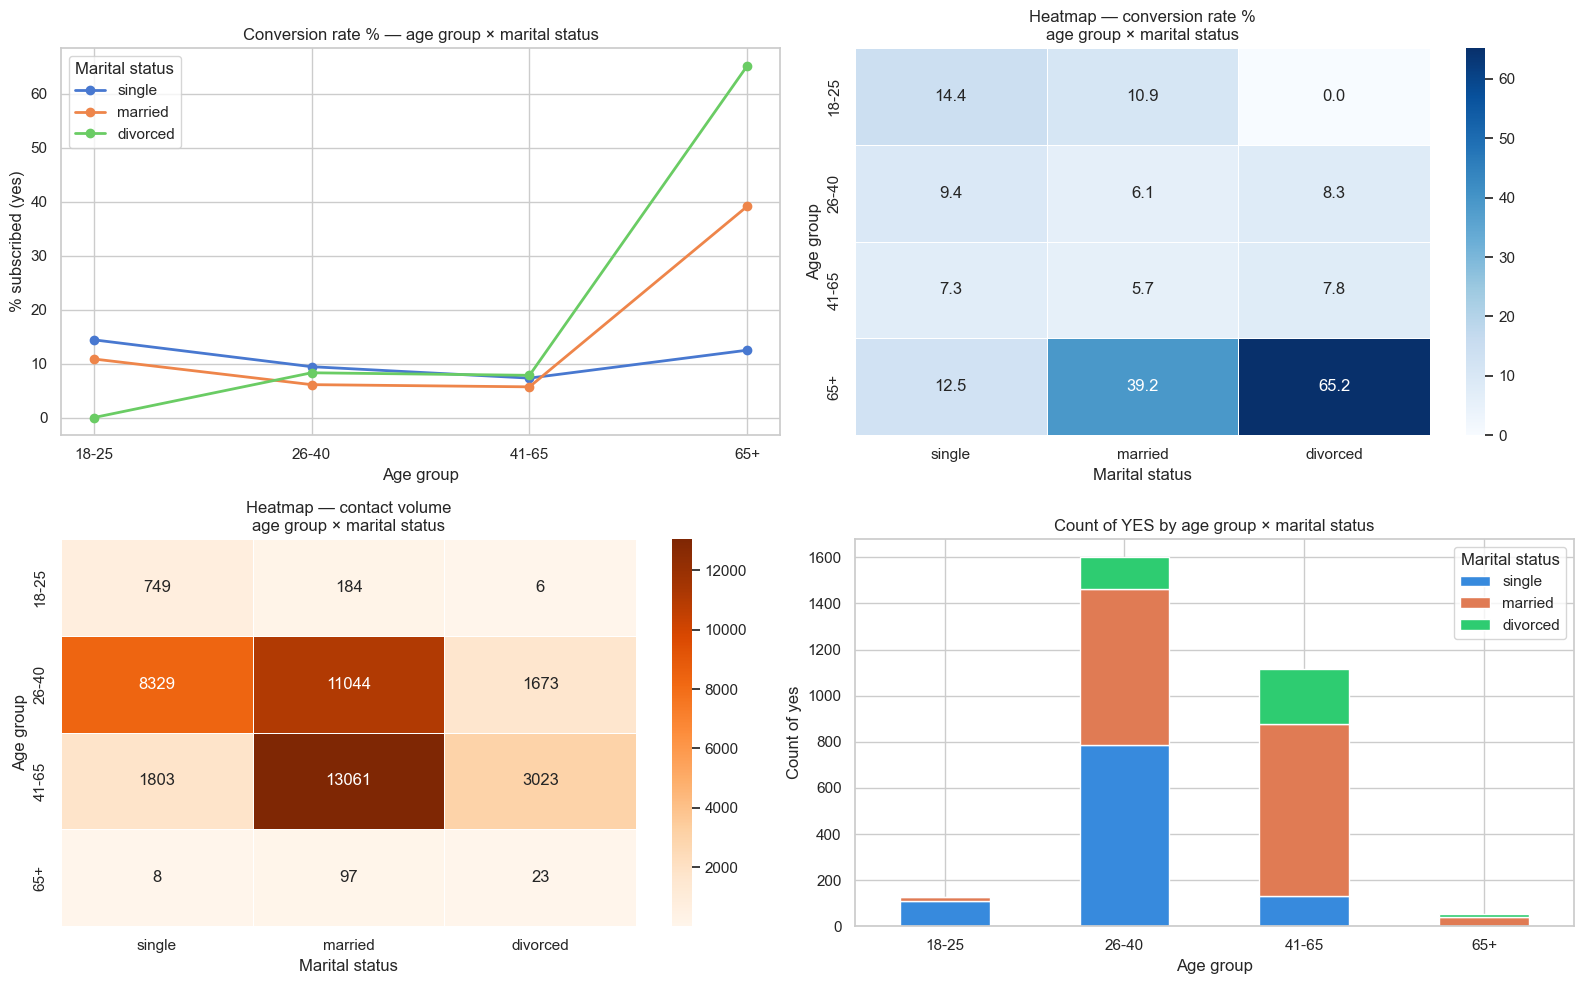


   CONVERSION RATE — AGE GROUP × MARITAL STATUS
marital    single  married  divorced
age_group                           
18-25        14.4     10.9       0.0
26-40         9.4      6.1       8.3
41-65         7.3      5.7       7.8
65+          12.5     39.2      65.2

   VOLUME — AGE GROUP × MARITAL STATUS
marital    single  married  divorced
age_group                           
18-25         749      184         6
26-40        8329    11044      1673
41-65        1803    13061      3023
65+             8       97        23

   SIGNAL STRENGTH — rate > 10% AND volume > 100
   these combinations are worth targeting
  ✅ 18-25    × single     rate=14.4%  volume=749
  ✅ 18-25    × married    rate=10.9%  volume=184


In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

marital_order = ['single', 'married', 'divorced']

# ── plot 1 : conversion rate by marital + age group ──────────────────
age_marital_conv = (eda_df.groupby(['age_group', 'marital'])['y']
                       .apply(lambda x: (x == 'yes').mean() * 100)
                       .reset_index(name='pct_yes'))

for marital in marital_order:
    subset = age_marital_conv[
        age_marital_conv['marital'] == marital]
    axes[0][0].plot(
        subset['age_group'].astype(str),
        subset['pct_yes'],
        marker='o', linewidth=2, label=marital)

axes[0][0].set_title('Conversion rate % — age group × marital status')
axes[0][0].set_xlabel('Age group')
axes[0][0].set_ylabel('% subscribed (yes)')
axes[0][0].legend(title='Marital status')

# ── plot 2 : heatmap — age group vs marital conversion rate ──────────
pivot_conv = (eda_df.groupby(['age_group', 'marital'])['y']
                 .apply(lambda x: (x == 'yes').mean() * 100)
                 .unstack(fill_value=0)
                 .reindex(columns=marital_order))

import seaborn as sns
sns.heatmap(pivot_conv,
            annot=True, fmt='.1f',
            cmap='Blues',
            linewidths=0.5,
            ax=axes[0][1])
axes[0][1].set_title('Heatmap — conversion rate %\n'
                     'age group × marital status')
axes[0][1].set_xlabel('Marital status')
axes[0][1].set_ylabel('Age group')

# ── plot 3 : count heatmap — volume check ────────────────────────────
pivot_count = (eda_df.groupby(['age_group', 'marital'])['y']
                   .count()
                   .unstack(fill_value=0)
                   .reindex(columns=marital_order))

sns.heatmap(pivot_count,
            annot=True, fmt='d',
            cmap='Oranges',
            linewidths=0.5,
            ax=axes[1][0])
axes[1][0].set_title('Heatmap — contact volume\n'
                     'age group × marital status')
axes[1][0].set_xlabel('Marital status')
axes[1][0].set_ylabel('Age group')

# ── plot 4 : stacked bar — yes count by marital within each age group──
age_marital_counts = (eda_df[eda_df['y'] == 'yes']
                         .groupby(['age_group', 'marital'])
                         .size()
                         .unstack(fill_value=0)
                         .reindex(columns=marital_order))

age_marital_counts.plot(
    kind='bar', stacked=True, ax=axes[1][1],
    color=['#378add', '#e07b54', '#2ecc71'],
    edgecolor='white')
axes[1][1].set_title('Count of YES by age group × marital status')
axes[1][1].set_xlabel('Age group')
axes[1][1].set_ylabel('Count of yes')
axes[1][1].tick_params(axis='x', rotation=0)
axes[1][1].legend(title='Marital status')

plt.tight_layout()
plt.show()

# ── print signal table ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("   CONVERSION RATE — AGE GROUP × MARITAL STATUS")
print("=" * 60)
print(pivot_conv.round(1).to_string())
print("\n" + "=" * 60)
print("   VOLUME — AGE GROUP × MARITAL STATUS")
print("=" * 60)
print(pivot_count.to_string())
print("\n" + "=" * 60)
print("   SIGNAL STRENGTH — rate > 10% AND volume > 100")
print("   these combinations are worth targeting")
print("=" * 60)

# flag strong signals — high rate AND enough volume
for age in pivot_conv.index:
    for mar in marital_order:
        rate = pivot_conv.loc[age, mar]
        vol  = pivot_count.loc[age, mar]
        if rate > 10 and vol > 100:
            print(f"  ✅ {age:<8} × {mar:<10} "
                  f"rate={rate:.1f}%  volume={vol}")
print("=" * 60)

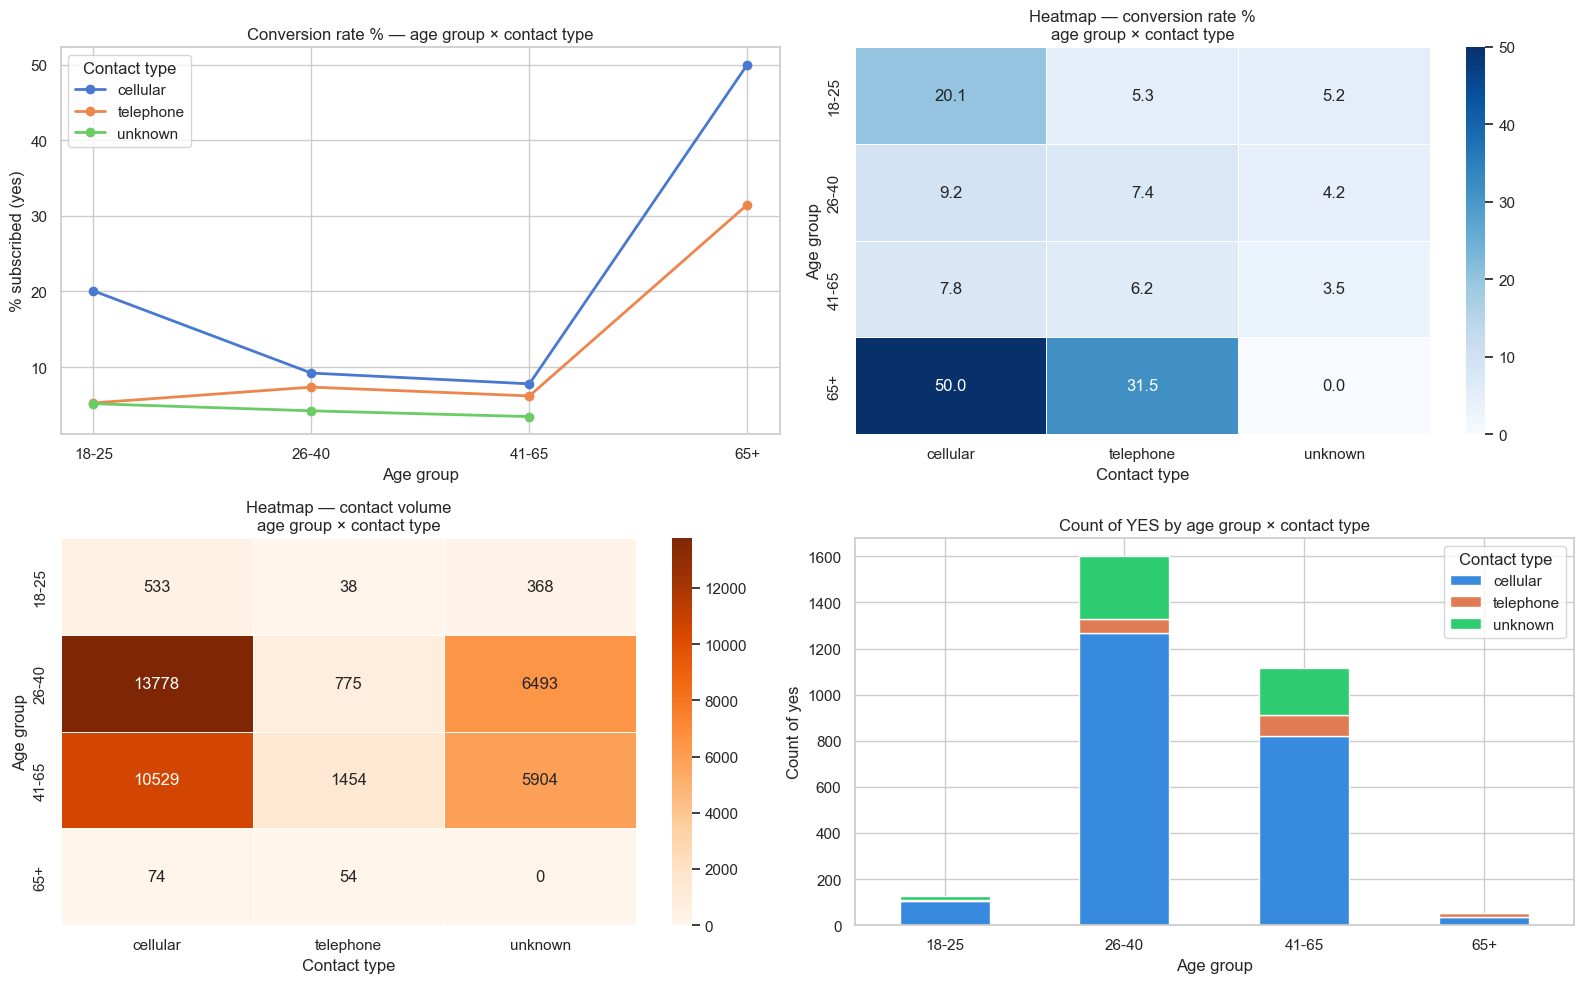


   CONVERSION RATE — AGE GROUP × CONTACT TYPE
contact    cellular  telephone  unknown
age_group                              
18-25          20.1        5.3      5.2
26-40           9.2        7.4      4.2
41-65           7.8        6.2      3.5
65+            50.0       31.5      0.0

   VOLUME — AGE GROUP × CONTACT TYPE
contact    cellular  telephone  unknown
age_group                              
18-25           533         38      368
26-40         13778        775     6493
41-65         10529       1454     5904
65+              74         54        0

   SIGNAL STRENGTH — rate > 10% AND volume > 100
   these combinations are worth targeting
  ✅ 18-25    × cellular     rate=20.1%  volume=533

   FEATURE ENGINEERING — age × contact interaction
 age_contact_flag  conversion_%
       low_signal           3.9
         moderate           7.2
            prime          23.7
standard_cellular           8.6


In [39]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

contact_order = ['cellular', 'telephone', 'unknown']

# ── plot 1 : conversion rate by age group + contact type ─────────────
age_contact_conv = (eda_df.groupby(['age_group', 'contact'])['y']
                       .apply(lambda x: (x == 'yes').mean() * 100)
                       .reset_index(name='pct_yes'))

for contact in contact_order:
    subset = age_contact_conv[
        age_contact_conv['contact'] == contact]
    axes[0][0].plot(
        subset['age_group'].astype(str),
        subset['pct_yes'],
        marker='o', linewidth=2, label=contact)

axes[0][0].set_title('Conversion rate % — age group × contact type')
axes[0][0].set_xlabel('Age group')
axes[0][0].set_ylabel('% subscribed (yes)')
axes[0][0].legend(title='Contact type')

# ── plot 2 : heatmap — age group vs contact conversion rate ──────────
pivot_conv = (eda_df.groupby(['age_group', 'contact'])['y']
                 .apply(lambda x: (x == 'yes').mean() * 100)
                 .unstack(fill_value=0)
                 .reindex(columns=contact_order))

import seaborn as sns
sns.heatmap(pivot_conv,
            annot=True, fmt='.1f',
            cmap='Blues',
            linewidths=0.5,
            ax=axes[0][1])
axes[0][1].set_title('Heatmap — conversion rate %\n'
                     'age group × contact type')
axes[0][1].set_xlabel('Contact type')
axes[0][1].set_ylabel('Age group')

# ── plot 3 : count heatmap — volume check ────────────────────────────
pivot_count = (eda_df.groupby(['age_group', 'contact'])['y']
                   .count()
                   .unstack(fill_value=0)
                   .reindex(columns=contact_order))

sns.heatmap(pivot_count,
            annot=True, fmt='d',
            cmap='Oranges',
            linewidths=0.5,
            ax=axes[1][0])
axes[1][0].set_title('Heatmap — contact volume\n'
                     'age group × contact type')
axes[1][0].set_xlabel('Contact type')
axes[1][0].set_ylabel('Age group')

# ── plot 4 : stacked bar — yes count by contact within each age group──
age_contact_counts = (eda_df[eda_df['y'] == 'yes']
                         .groupby(['age_group', 'contact'])
                         .size()
                         .unstack(fill_value=0)
                         .reindex(columns=contact_order))

age_contact_counts.plot(
    kind='bar', stacked=True, ax=axes[1][1],
    color=['#378add', '#e07b54', '#2ecc71'],
    edgecolor='white')
axes[1][1].set_title('Count of YES by age group × contact type')
axes[1][1].set_xlabel('Age group')
axes[1][1].set_ylabel('Count of yes')
axes[1][1].tick_params(axis='x', rotation=0)
axes[1][1].legend(title='Contact type')

plt.tight_layout()
plt.show()

# ── print signal table ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("   CONVERSION RATE — AGE GROUP × CONTACT TYPE")
print("=" * 60)
print(pivot_conv.round(1).to_string())
print("\n" + "=" * 60)
print("   VOLUME — AGE GROUP × CONTACT TYPE")
print("=" * 60)
print(pivot_count.to_string())
print("\n" + "=" * 60)
print("   SIGNAL STRENGTH — rate > 10% AND volume > 100")
print("   these combinations are worth targeting")
print("=" * 60)

for age in pivot_conv.index:
    for contact in contact_order:
        rate = pivot_conv.loc[age, contact]
        vol  = pivot_count.loc[age, contact]
        if rate > 10 and vol > 100:
            print(f"  ✅ {age:<8} × {contact:<12} "
                  f"rate={rate:.1f}%  volume={vol}")

print("=" * 60)

# ── feature engineering suggestion from this analysis ─────────────────
print("\n" + "=" * 60)
print("   FEATURE ENGINEERING — age × contact interaction")
print("=" * 60)

# flag the high signal combinations found above
def age_contact_flag(row):
    age     = str(row['age_group'])
    contact = str(row['contact'])

    # 65+ cellular — highest yes rate regardless of volume
    if age == '65+' and contact == 'cellular':
        return 'prime'

    # 18-25 cellular — good rate, underreached
    elif age == '18-25' and contact == 'cellular':
        return 'prime'

    # any cellular with decent age group
    elif contact == 'cellular' and age in ['26-40', '41-65']:
        return 'standard_cellular'

    # unknown contact — worst performing
    elif contact == 'unknown':
        return 'low_signal'

    # telephone — moderate
    elif contact == 'telephone':
        return 'moderate'

    else:
        return 'other'

eda_df['age_contact_flag'] = eda_df.apply(
    age_contact_flag, axis=1)

print(eda_df.groupby('age_contact_flag')['y'].apply(
    lambda x: (x == 'yes').mean() * 100).round(1)
    .reset_index(name='conversion_%').to_string(index=False))
print("=" * 60)

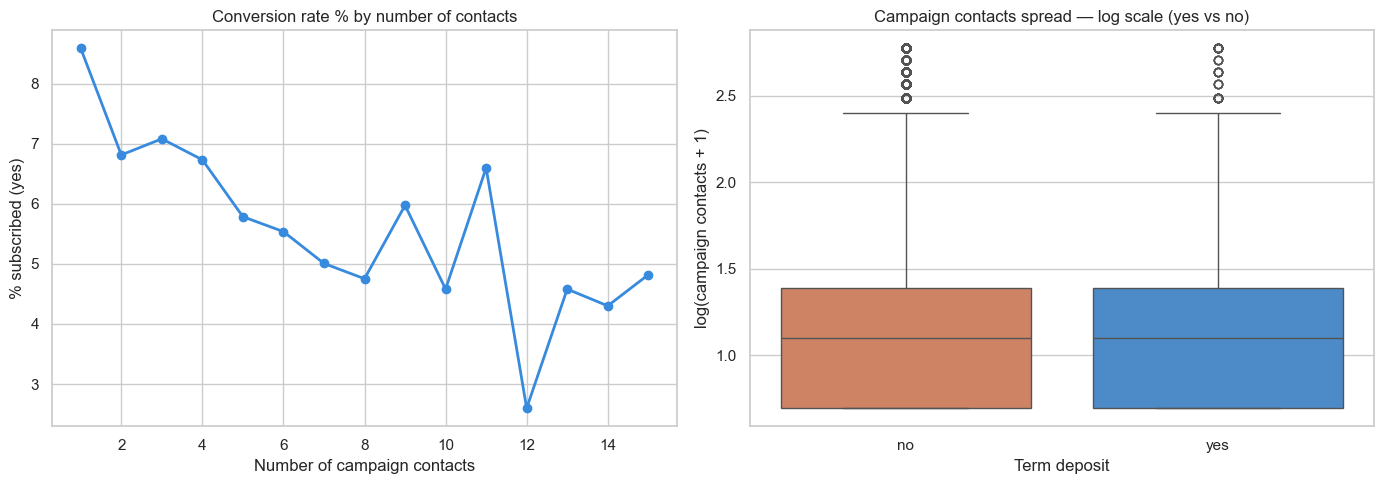

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# clip outliers — most contacts are under 15
camp_clip = eda_df[eda_df['campaign'] <= 15]

camp_conv = (camp_clip.groupby('campaign')['y']
               .apply(lambda x: (x == 'yes').mean() * 100)
               .reset_index(name='pct_yes'))
axes[0].plot(camp_conv['campaign'], camp_conv['pct_yes'],
           marker='o', color='#378add', linewidth=2)
axes[0].set_title('Conversion rate % by number of contacts')
axes[0].set_xlabel('Number of campaign contacts')
axes[0].set_ylabel('% subscribed (yes)')

# clip first then log transform
eda_df['campaign_log'] = np.log1p(eda_df['campaign'].clip(upper=15))

sns.boxplot(data=eda_df, x='y', y='campaign_log', ax=axes[1],
            order=['no', 'yes'], palette=COLORS)
axes[1].set_title('Campaign contacts spread — log scale (yes vs no)')
axes[1].set_xlabel('Term deposit')
axes[1].set_ylabel('log(campaign contacts + 1)')

plt.tight_layout()
plt.show()

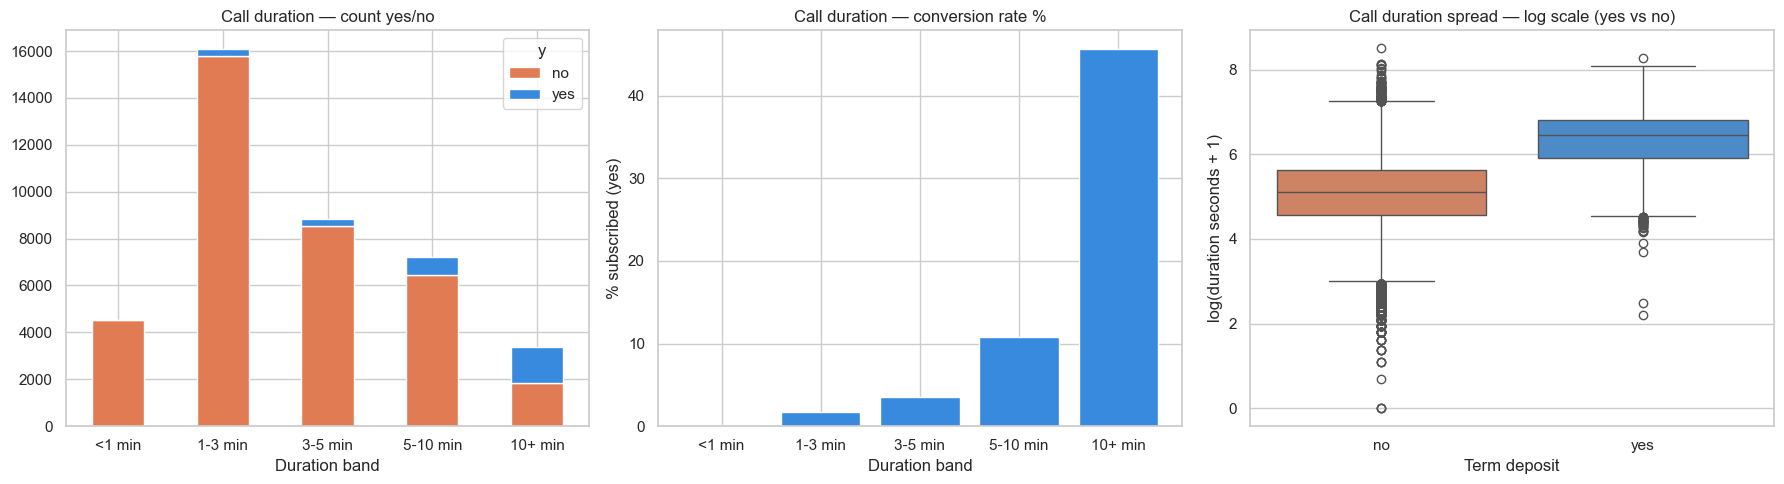

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# bin duration in seconds into readable groups
eda_df['dur_group'] = pd.cut(eda_df['duration'],
    bins=[0, 60, 180, 300, 600, 99999],
    labels=['<1 min', '1-3 min', '3-5 min', '5-10 min', '10+ min'])

dur_order = ['<1 min', '1-3 min', '3-5 min', '5-10 min', '10+ min']

# stacked count bar
dur_counts = pd.crosstab(eda_df['dur_group'], eda_df['y'])[
    ['no', 'yes']].reindex(dur_order)
dur_counts.plot(kind='bar', stacked=True, ax=axes[0],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
axes[0].set_title('Call duration — count yes/no')
axes[0].set_xlabel('Duration band')
axes[0].tick_params(axis='x', rotation=0)

# conversion rate bar
dur_conv = (eda_df.groupby('dur_group', observed=True)['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reindex(dur_order)
              .reset_index(name='pct_yes'))
axes[1].bar(dur_conv['dur_group'].astype(str), dur_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[1].set_title('Call duration — conversion rate %')
axes[1].set_xlabel('Duration band')
axes[1].set_ylabel('% subscribed (yes)')
axes[1].tick_params(axis='x', rotation=0)

# box plot with log scale to handle skew
eda_df['duration_log'] = np.log1p(eda_df['duration'])
sns.boxplot(data=eda_df, x='y', y='duration_log', ax=axes[2],
            order=['no', 'yes'], palette=COLORS)
axes[2].set_title('Call duration spread — log scale (yes vs no)')
axes[2].set_xlabel('Term deposit')
axes[2].set_ylabel('log(duration seconds + 1)')

plt.tight_layout()
plt.show()

IQR upper fence cap : 632 seconds
IQR lower fence cap : -220 seconds
Values capped       : 3000 rows


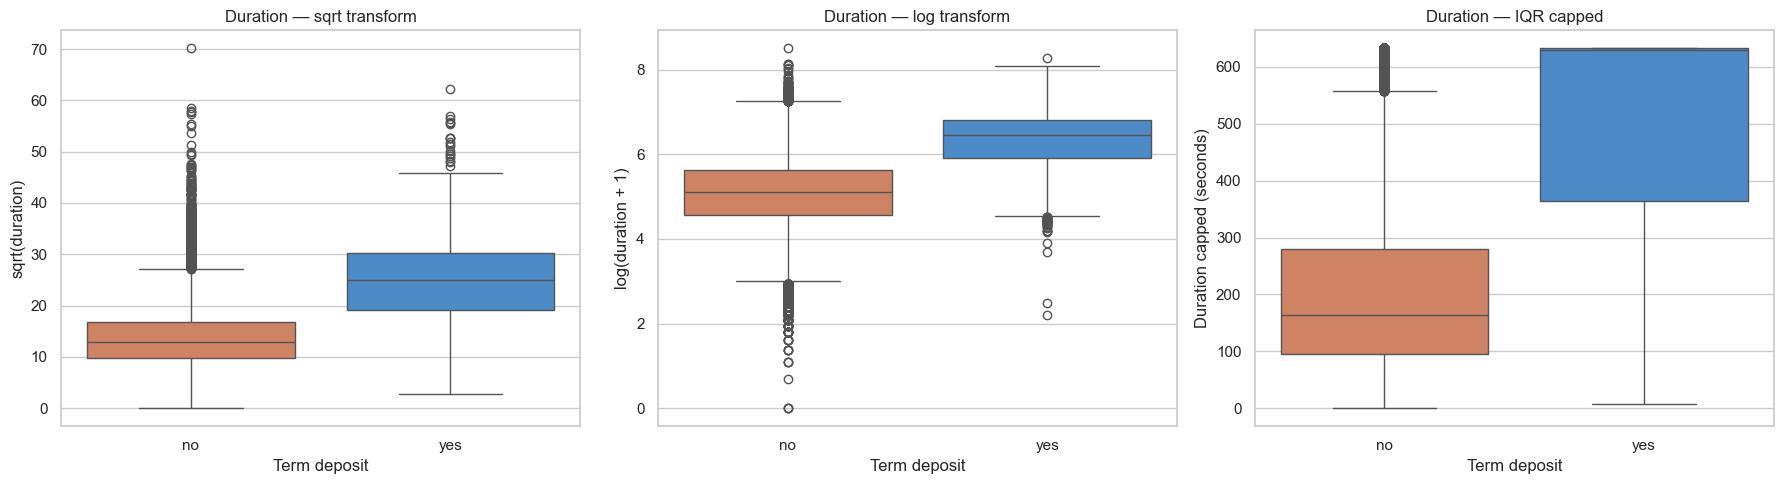

In [42]:
# three transformations to compare
eda_df['duration_log']  = np.log1p(eda_df['duration'])
eda_df['duration_sqrt'] = np.sqrt(eda_df['duration'])

# IQR capping — cap anything beyond 1.5*IQR at the fence
Q1  = eda_df['duration'].quantile(0.25)
Q3  = eda_df['duration'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR

eda_df['duration_capped'] = eda_df['duration'].clip(
    lower=lower_fence, upper=upper_fence)

print(f"IQR upper fence cap : {upper_fence:.0f} seconds")
print(f"IQR lower fence cap : {lower_fence:.0f} seconds")
print(f"Values capped       : {(eda_df['duration'] > upper_fence).sum()} rows")

# plot all three side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# sqrt
sns.boxplot(data=eda_df, x='y', y='duration_sqrt', ax=axes[0],
            order=['no', 'yes'], palette=COLORS)
axes[0].set_title('Duration — sqrt transform')
axes[0].set_xlabel('Term deposit')
axes[0].set_ylabel('sqrt(duration)')

# log
sns.boxplot(data=eda_df, x='y', y='duration_log', ax=axes[1],
            order=['no', 'yes'], palette=COLORS)
axes[1].set_title('Duration — log transform')
axes[1].set_xlabel('Term deposit')
axes[1].set_ylabel('log(duration + 1)')

# IQR capped
sns.boxplot(data=eda_df, x='y', y='duration_capped', ax=axes[2],
            order=['no', 'yes'], palette=COLORS)
axes[2].set_title('Duration — IQR capped')
axes[2].set_xlabel('Term deposit')
axes[2].set_ylabel('Duration capped (seconds)')

plt.tight_layout()
plt.show()

# 📊 EDA Summary — Bank Term Deposit Campaign

---

## 1. Age
- **65+** → highest conversion (~42%) but tiny sample — not scalable alone
- **18-25** → decent conversion (~13.5%) but underreached by the campaign
- **26-40** → largest group (~21,000) but only 7.5% conversion
- **41-65** → second largest (~18,000) with worst conversion at 6.3%
- **Insight:** Campaign is spending most effort on the least receptive age groups

---

## 2. Education
- **Tertiary** → best conversion (~9%) — university educated, financially literate
- **Secondary** → most targeted (~21,000) but average conversion (~7%)
- **Primary** → lowest conversion (~6%)
- **Unknown** → treat carefully, may need imputation
- **Feature Engineering Tip:** Cross secondary with job type
```python
  eda_df['edu_job'] = eda_df['education'] + '_' + eda_df['job']
  # secondary_technician vs secondary_blue-collar behave differently
```

---

## 3. Balance
- Consistent positive signal — higher balance = higher conversion
- Conversion rises from **5.4% (negative balance)** → **9.7% (2k-5k band)**
- Heavy right skew handled with **log transformation**
- Moderate predictor on its own but reliable direction

---

## 4. Housing & Personal Loan
- Clients **without any loan** convert significantly better
- **Housing loan** gap: 8.9% (no loan) vs 6.1% (has loan) — stronger signal
- **Personal loan** gap: 7.4% (no loan) vs 5.4% (has loan) — weaker signal
- Personal loan holders are a minority (~6,500 of 40,000)
- **Feature Engineering Tip:** Combine both into a debt burden score
```python
  eda_df['debt_burden'] = (
      (eda_df['housing'] == 'yes').astype(int) +
      (eda_df['loan'] == 'yes').astype(int)
  )
  # 0 = no loans, 1 = one loan, 2 = both loans
```

---

## 5. Contact Type
- **Cellular** → best channel: highest volume (~25,000) AND best conversion (~9%)
- **Telephone** → small volume (~2,500) with decent conversion (~7.2%)
- **Unknown** → ~12,500 records (nearly a third of data), worst conversion (~4%)
- Unknown kept as its own category — likely a missing data pattern the model can learn from

---

## 6. Day & Month
- **Day of month** → weak and noisy signal, no consistent pattern
- **Best months** → March (~48%), October (~61%) but very low volume
- **Worst months** → May has ~13,500 contacts but only 6% conversion
- **Insight:** Campaign calendar needs rethinking — heaviest effort in worst months
- **Feature Engineering Tip:**
```python
  high_conv_months = ['mar', 'apr', 'oct']
  eda_df['is_high_conv_month'] = eda_df['month'].isin(high_conv_months).astype(int)
```

---

## 7. Campaign Contacts
- First contact → **8.5% conversion** — best result
- Conversion drops sharply after 3 contacts
- Yes and No groups have almost identical contact distributions
- **Insight:** Calling the same person repeatedly is wasted effort
```python
  eda_df['is_first_contact'] = (eda_df['campaign'] == 1).astype(int)
  eda_df['over_contacted']   = (eda_df['campaign'] > 3).astype(int)
```

---

## 8. Call Duration ⚠️
- **Strongest predictor** in the entire dataset
- Clear step-up pattern:

| Duration | Conversion |
|----------|------------|
| < 1 min  | ~0%        |
| 1-3 min  | ~2%        |
| 3-5 min  | ~4%        |
| 5-10 min | ~11%       |
| 10+ min  | ~45%       |

- **Critical Warning — Data Leakage Risk:**
  > Duration is only known **after** the call ends. In real deployment the model cannot use this feature because you do not know call length before making the call.
- **Recommendation:** Train two versions
  - ✅ **With duration** — shows ceiling model performance
  - ✅ **Without duration** — real world deployable model

---

## 9. Credit Default
- Vast majority have no default (~39,000 vs ~800)
- Conversion gap is small: 7.3% (no default) vs 6% (has default)
- Heavily imbalanced column — weak standalone predictor
- Worth keeping as a feature but not a dominant signal

---

## Class Imbalance
| Class | Count | % |
|-------|-------|---|
| No    | 37,104 | 92.8% |
| Yes   | 2,896  | 7.2%  |

- Model must focus on **Recall of YES** — missing a real customer is costlier than a false alarm
- Use **threshold tuning** (lower from 0.5 → 0.3) to catch more yes cases

In [43]:
eda_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'y',
       'age_group', 'balance_log', 'bal_group', 'age_contact_flag',
       'campaign_log', 'dur_group', 'duration_log', 'duration_sqrt',
       'duration_capped'],
      dtype='str')

In [44]:
# cellular contact + high balance = premium target
eda_df['cellular_wealthy'] = (
    (eda_df['contact'] == 'cellular') &
    (eda_df['balance'] > 1000)
).astype(int)

# good month + cellular = ideal timing + channel
eda_df['prime_contact'] = (
    (eda_df['contact'] == 'cellular') &
    (eda_df['month'].isin(['mar', 'oct', 'apr']))
).astype(int)

# no debt + high balance = financially free client
eda_df['financially_free'] = (
    (eda_df['housing'] == 'no') &
    (eda_df['loan'] == 'no') &
    (eda_df['balance'] > 500)
).astype(int)

# tier 1 — high quality months (rate > 10% with meaningful volume)
# tier 2 — medium months (rate 6-10% or high volume)
# tier 3 — poor months (rate < 6% or no data)

month_tier_map = {
    'apr': 1, 'feb': 1,           # good rate + volume
    'mar': 1, 'oct': 1,           # exceptional rate (keep despite low volume)
    'dec': 2,                      # okay rate, low volume
    'jun': 2, 'aug': 2, 'nov': 2, # average
    'jan': 3, 'may': 3,           # worst ROI
    'jul': 3, 'sep': 3            # poor or no data
}

eda_df['month_tier'] = eda_df['month'].map(month_tier_map)

# based on day chart analysis
HIGH_DAYS   = [2, 4, 5, 10, 17, 21, 30]   # rate up + volume present
MEDIUM_DAYS = [3, 6, 7, 8, 14, 15, 16, 20]
AVOID_DAYS  = [19, 22, 23, 24, 25, 29, 31]

eda_df['day_tier'] = eda_df['day'].apply(
    lambda d: 1 if d in HIGH_DAYS
    else 2 if d in MEDIUM_DAYS
    else 3
)

# combined timing score
# logic: good month AND good day = prime window
#        good month AND bad day  = still worth trying
#        bad month  AND good day = marginal
#        bad month  AND bad day  = avoid

eda_df['timing_score'] = eda_df.apply(
    lambda row: (
        # both good — prime window
        1 if row['month_tier'] == 1 and row['day_tier'] == 1
        # month good, day average
        else 2 if row['month_tier'] == 1 and row['day_tier'] == 2
        # month average, day good
        else 3 if row['month_tier'] == 2 and row['day_tier'] == 1
        # both average
        else 4 if row['month_tier'] == 2 and row['day_tier'] == 2
        # anything involving poor month or poor day
        else 5
    ), axis=1
)
# if timing_score = 1 is prime and 5 is worst
# LR sees higher number = worse → negative coefficient
# flip it so higher number = better

eda_df['timing_score_inv'] = 6 - eda_df['timing_score']
# now 5 = prime window, 1 = avoid
# this should flip the coefficient from red to green
# the three conditions that together give the highest
# reliable signal — cellular + young or senior + not married 26-40

def prime_trio(row):
    age     = str(row['age_group'])
    contact = str(row['contact'])
    marital = str(row['marital'])

    # tier 1 — gold combinations
    if age == '65+' and contact == 'cellular':
        return 3   # 50% rate

    if age == '18-25' and contact == 'cellular':
        return 3   # 20% rate

    if age == '65+' and marital in ['married', 'divorced']:
        return 3   # 39-65% rate

    # tier 2 — good combinations
    if contact == 'cellular' and age == '26-40':
        return 2   # 9.2% rate

    if age == '18-25' and marital == 'single':
        return 2   # 14.4% rate

    # tier 3 — dead zones
    if contact == 'unknown':
        return 0   # 3-5% across all groups

    if age == '41-65' and marital == 'married':
        return 0   # 5.7% — below base rate

    # everything else
    return 1

eda_df['prime_trio'] = eda_df.apply(prime_trio, axis=1)

prime_months = ['mar', 'apr', 'oct', 'feb']

eda_df['cellular_prime_month'] = (
    (eda_df['contact'] == 'cellular') &
    (eda_df['month'].isin(prime_months))
).astype(int)

# SHAP Analysis 

Total dataset      : 40000 rows
Layer 1 (campaign==1): 40000 rows
Removed            : 0 rows

Columns after drop: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'y', 'age_group', 'balance_log', 'bal_group', 'age_contact_flag', 'cellular_wealthy', 'prime_contact', 'financially_free', 'month_tier', 'day_tier', 'timing_score', 'timing_score_inv', 'prime_trio', 'cellular_prime_month']

Demographic features  : ['age', 'age_group', 'job', 'marital', 'education', 'default', 'balance_log', 'bal_group', 'housing', 'loan']
Call history features : ['month', 'day', 'contact']
Total features        : 13

Target distribution (first contact only):
  no  : 37104 (92.8%)
  yes : 2896 (7.2%)

   SECTION 1 — FULL EDA (Layer 1, no duration)


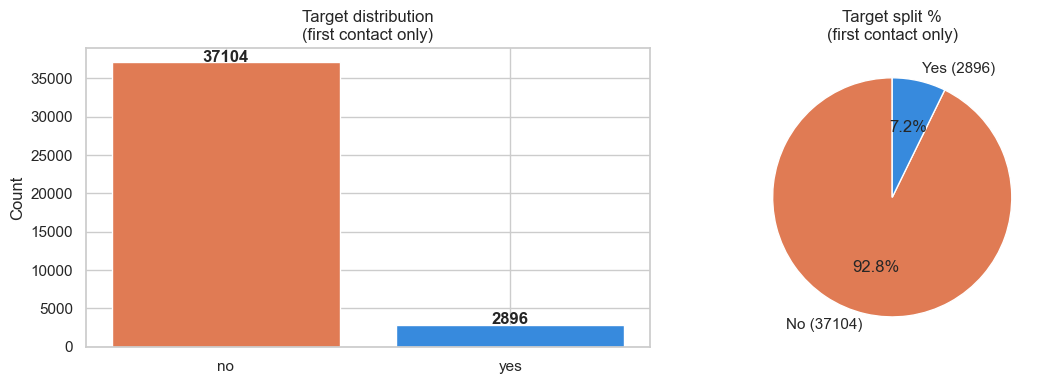

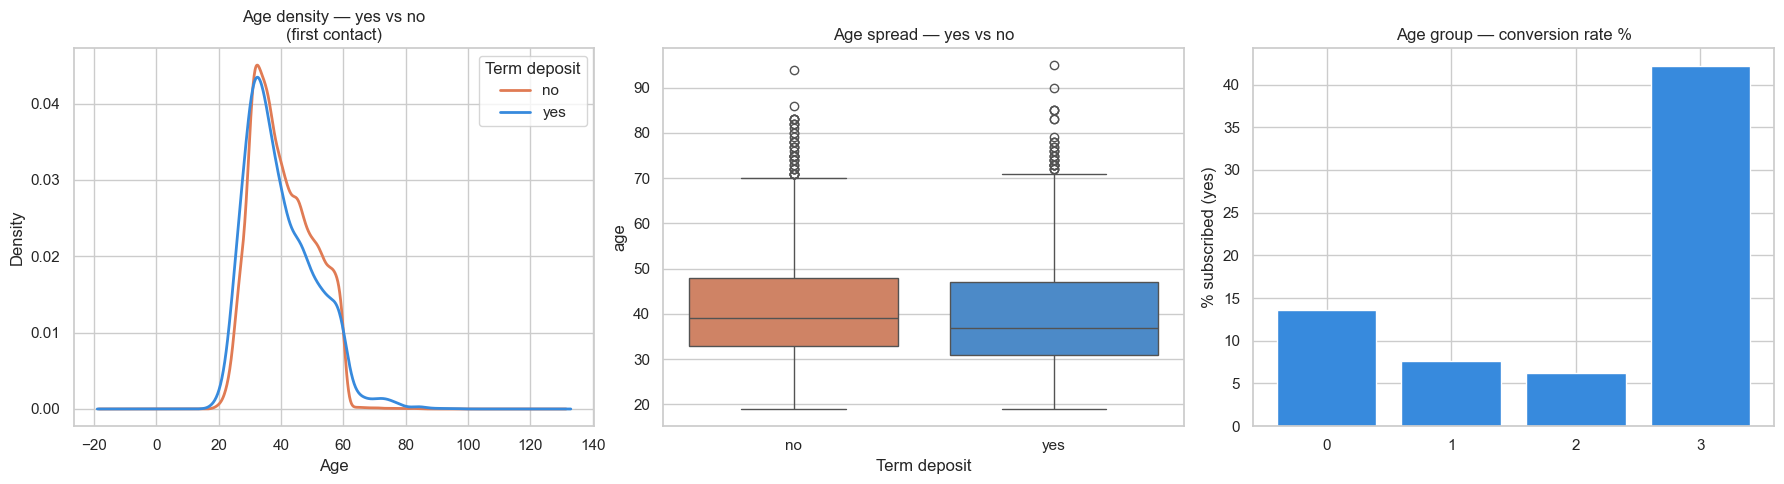

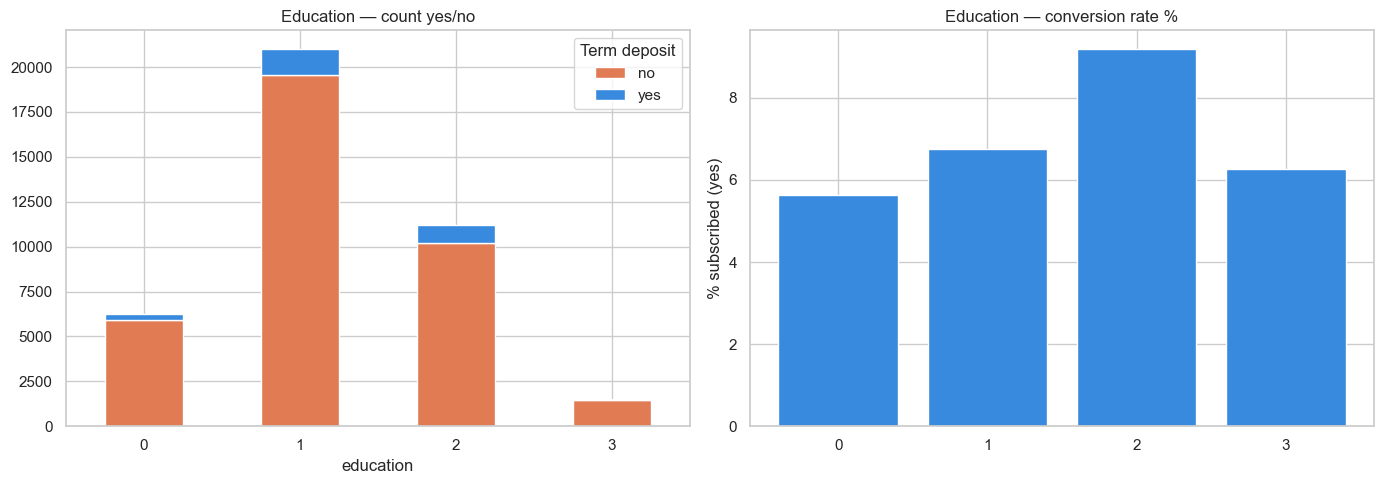

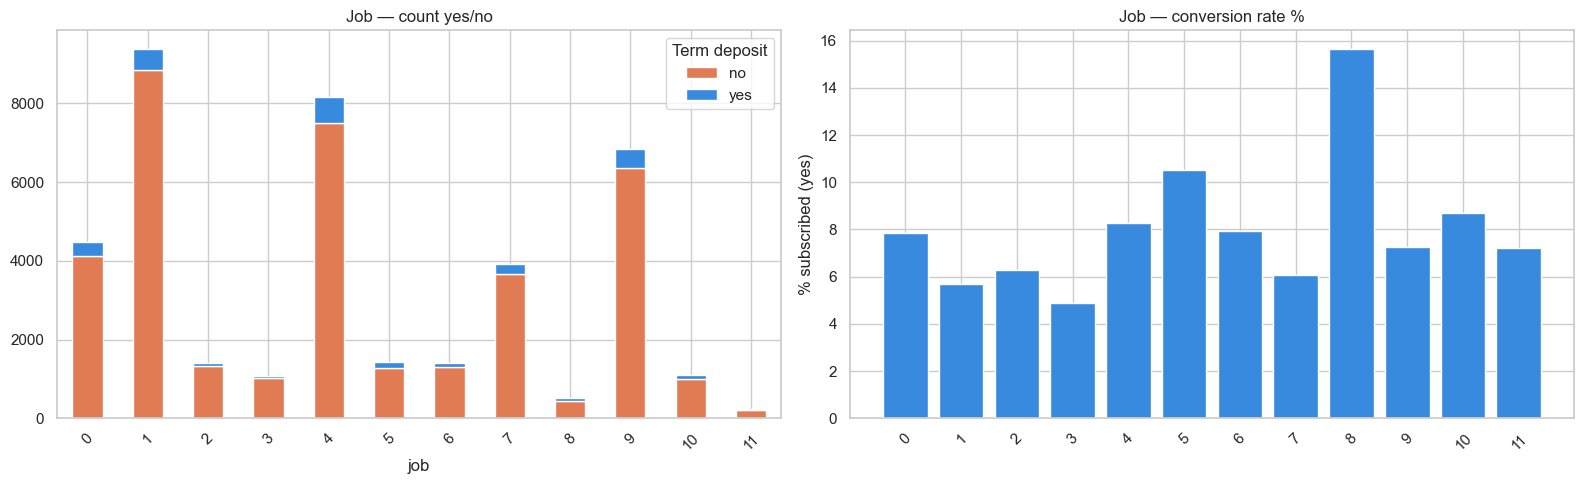

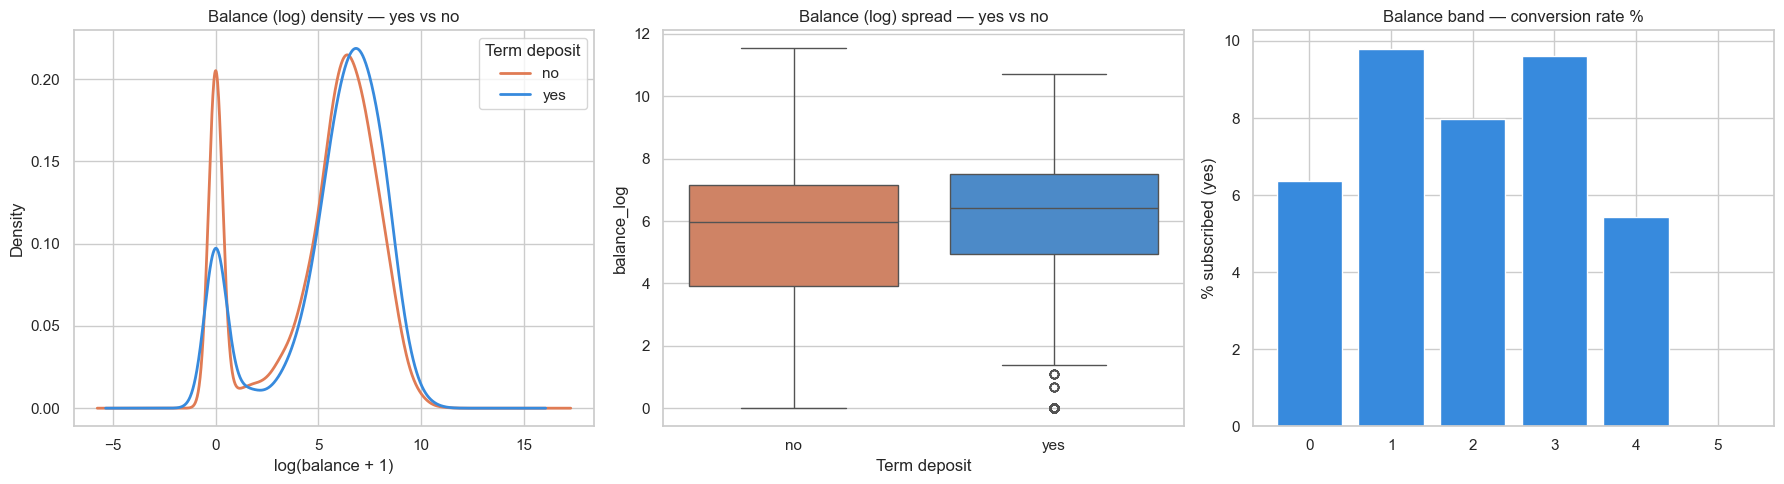

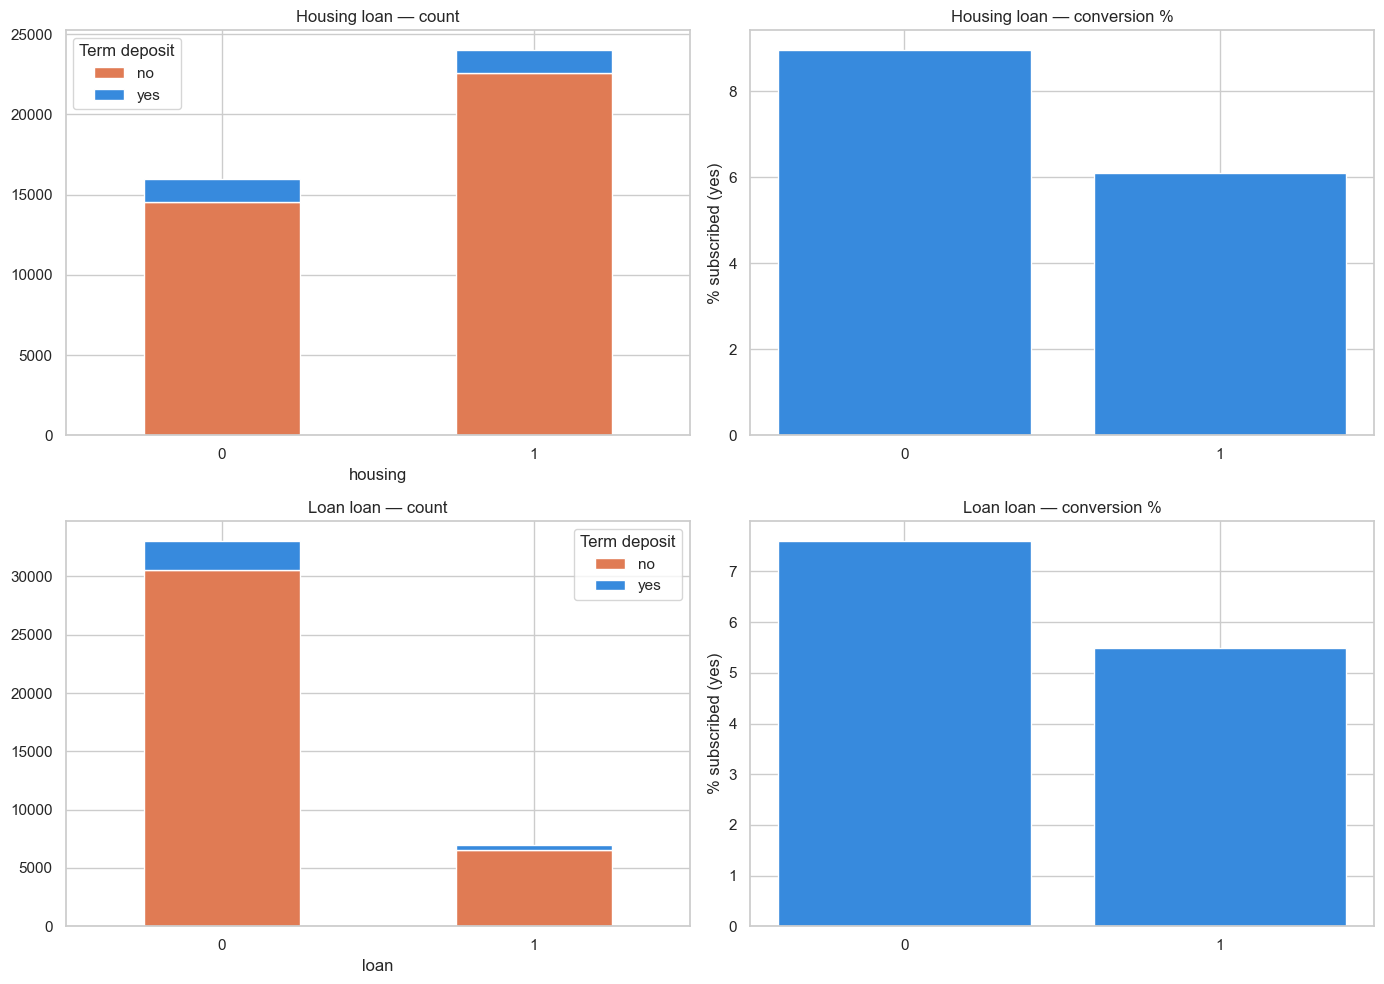

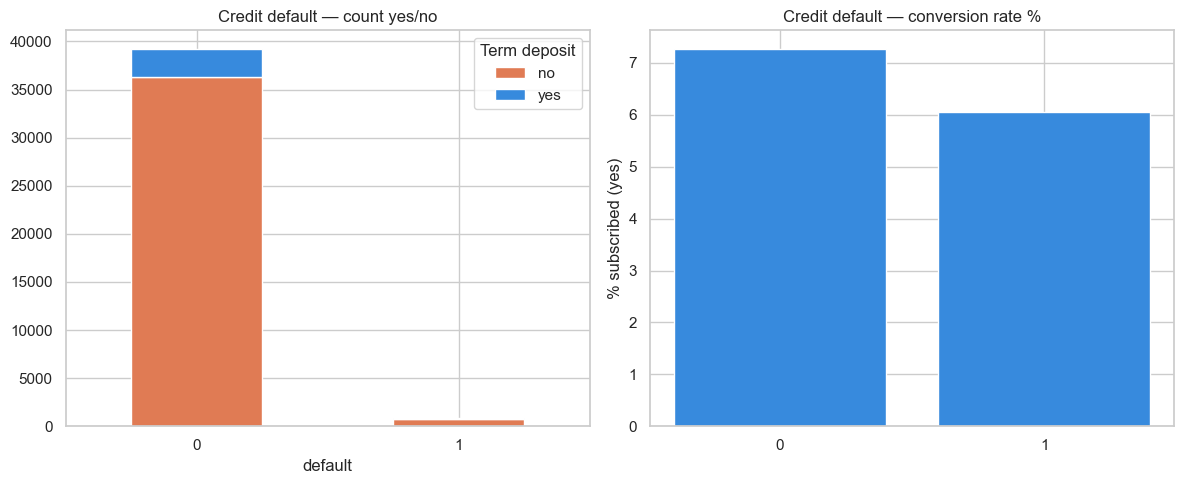

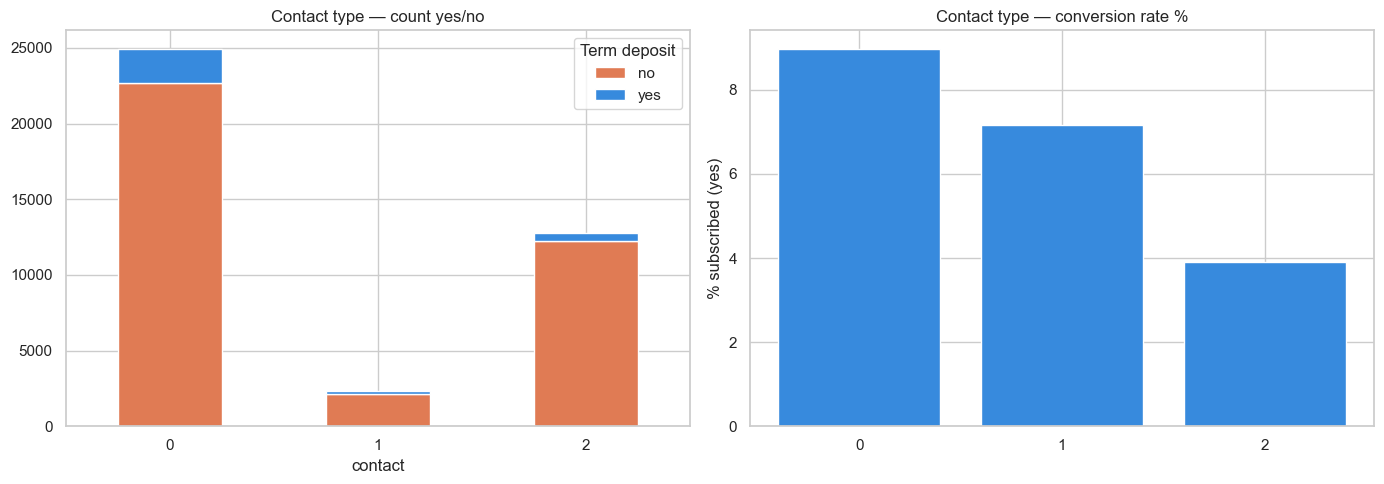

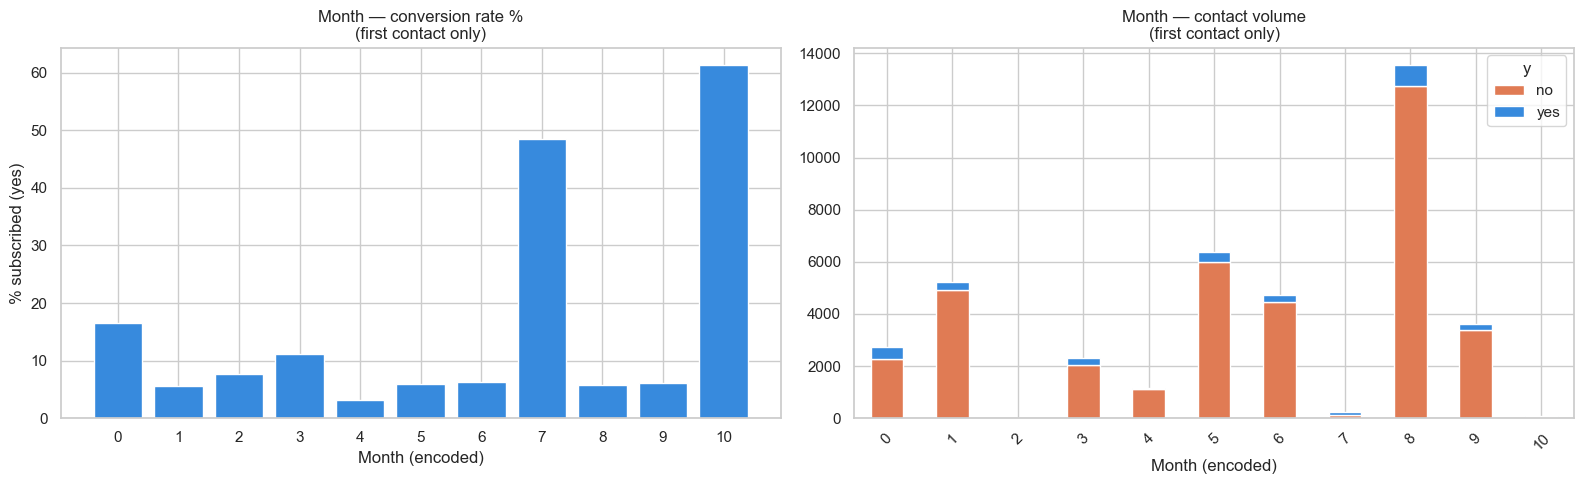

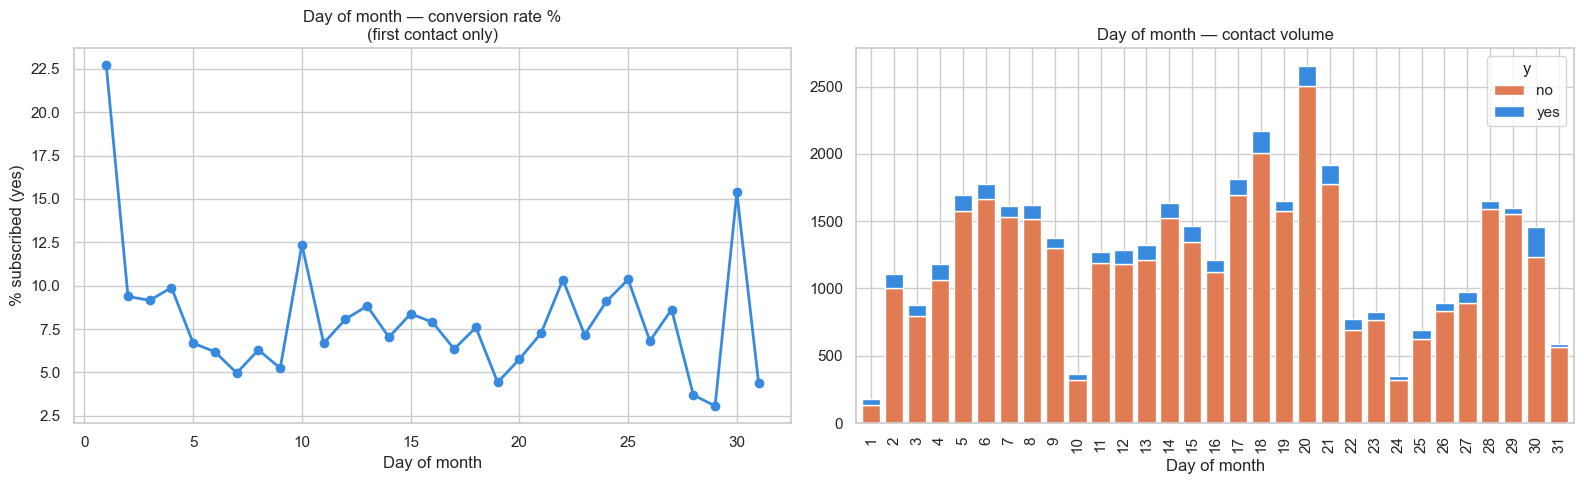

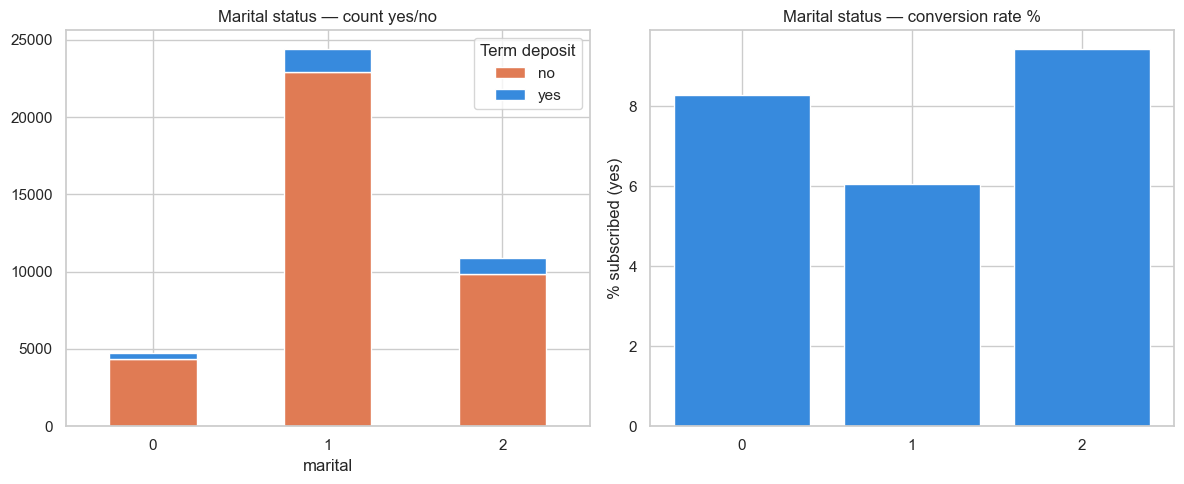


   SECTION 2 — SHAP ANALYSIS
   which features relate most to term deposit decision

SHAP aligned ✓  shape: (1000, 13)


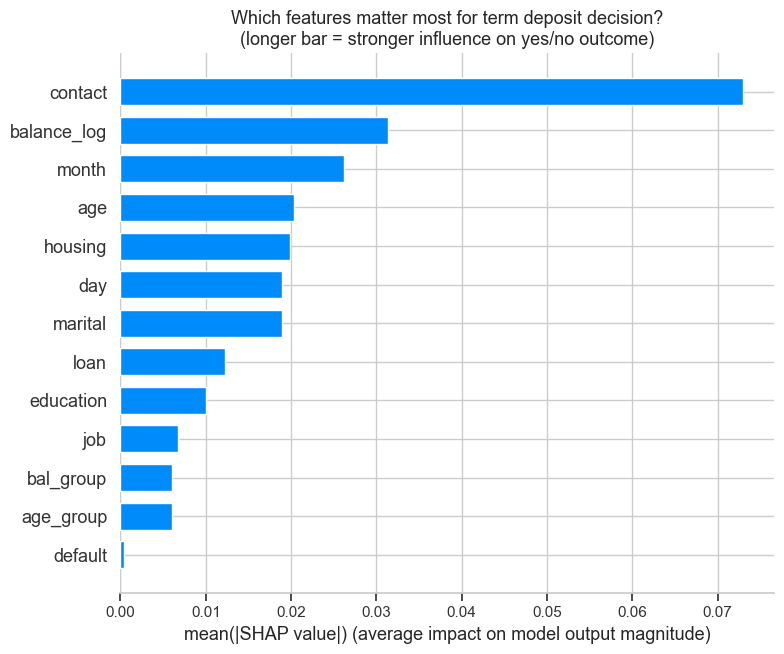

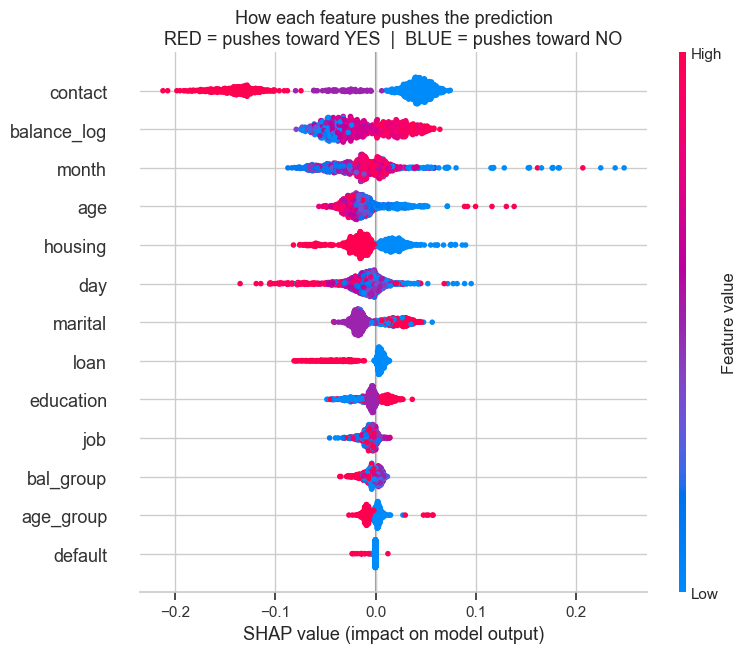


   SHAP RANKING — DEMOGRAPHIC vs CALL HISTORY
    feature  mean_abs_shap        group
    contact       0.072950 call_history
balance_log       0.031401  demographic
      month       0.026247 call_history
        age       0.020358  demographic
    housing       0.019850  demographic
        day       0.018981 call_history
    marital       0.018966  demographic
       loan       0.012289  demographic
  education       0.010045  demographic
        job       0.006750  demographic
  bal_group       0.006020  demographic
  age_group       0.005993  demographic
    default       0.000465  demographic

   GROUP TOTAL SHAP IMPACT
  Demographic  : 0.1321
  Call history : 0.1182


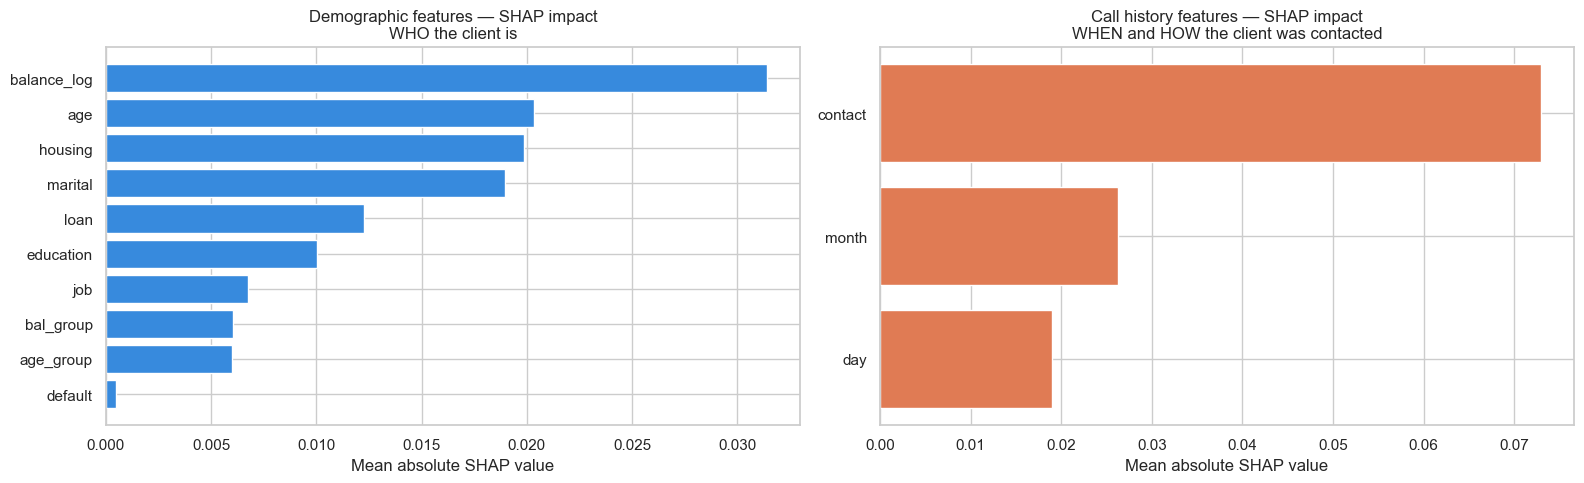


Top 3 features by SHAP impact: ['contact', 'balance_log', 'month']


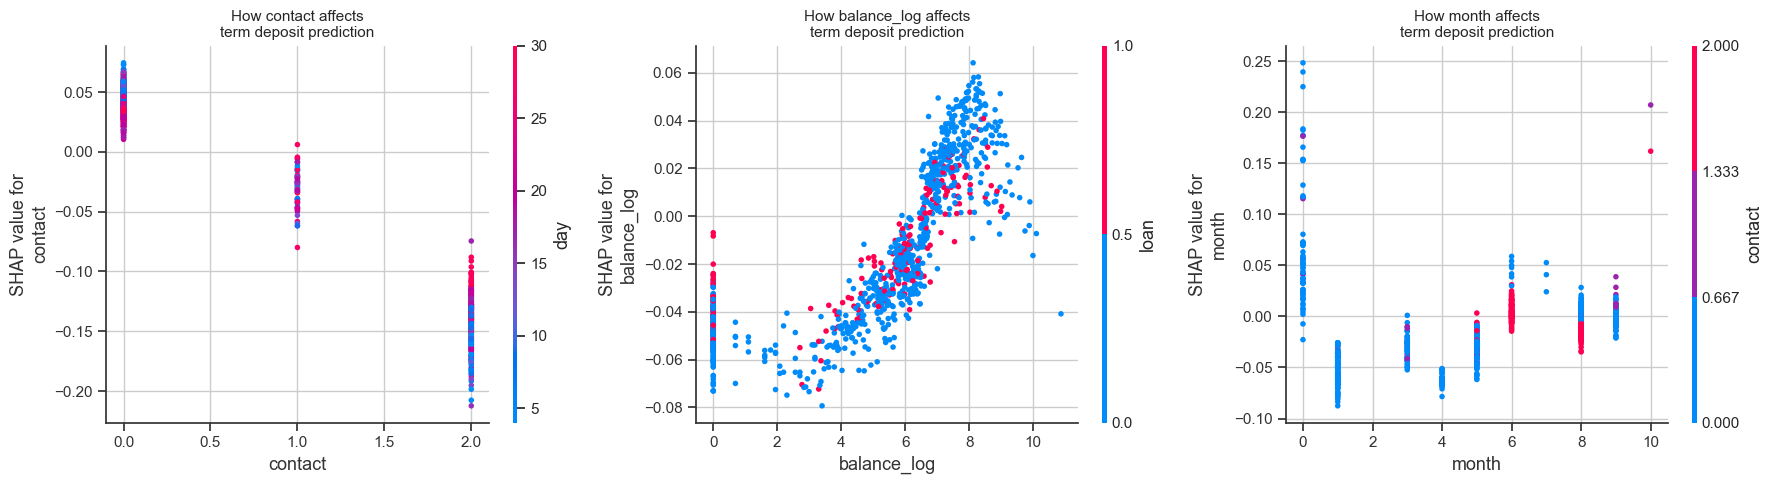


   PLAIN ENGLISH SHAP SUMMARY
   (for non-technical stakeholders)
  📅 WHEN  contact         ████████████████████████████████████ 0.0730
  👤 WHO  balance_log     ███████████████ 0.0314
  📅 WHEN  month           █████████████ 0.0262
  👤 WHO  age             ██████████ 0.0204
  👤 WHO  housing         █████████ 0.0199
  📅 WHEN  day             █████████ 0.0190
  👤 WHO  marital         █████████ 0.0190
  👤 WHO  loan            ██████ 0.0123
  👤 WHO  education       █████ 0.0100
  👤 WHO  job             ███ 0.0068
  👤 WHO  bal_group       ███ 0.0060
  👤 WHO  age_group       ██ 0.0060
  👤 WHO  default          0.0005

  HOW TO READ THIS:
  👤 WHO  = about the client's personal profile
  📅 WHEN = about when and how the call was made
  Longer bar = stronger influence on yes/no decision


In [45]:
from sklearn.preprocessing import LabelEncoder
import shap
import numpy as np

# ── 1. filter first contact only ────────────────────────────────────
layer1_df = eda_df.copy()

print(f"Total dataset      : {len(eda_df)} rows")
print(f"Layer 1 (campaign==1): {len(layer1_df)} rows")
print(f"Removed            : {len(eda_df) - len(layer1_df)} rows")

# ── 2. drop duration and campaign cols ──────────────────────────────
drop_cols = ['duration', 'campaign', 'campaign_log',
             'dur_group', 'duration_log', 'duration_sqrt',
             'duration_capped', 'engagement', 'engagement_bin',
             'engagement_enc']

layer1_df = layer1_df.drop(
    columns=[c for c in drop_cols if c in layer1_df.columns])

print(f"\nColumns after drop: {list(layer1_df.columns)}")

# ── 3. define feature lists ──────────────────────────────────────────
# clearly separated so non-technical stakeholders
# can see which group each feature belongs to

DEMOGRAPHIC_COLS = [
    'age',          # numeric — client age
    'age_group',    # binned age group
    'job',          # occupation
    'marital',      # marital status
    'education',    # education level
    'default',      # has credit default
    'balance_log',  # log of yearly balance
    'bal_group',    # balance band
    'housing',      # has housing loan
    'loan'          # has personal loan
]

CALL_HISTORY_COLS = [
    'month',        # last contact month
    'day',          # last contact day of month
    'contact'       # contact type (cellular/telephone/unknown)
]

ALL_FEATURES = DEMOGRAPHIC_COLS + CALL_HISTORY_COLS

print(f"\nDemographic features  : {DEMOGRAPHIC_COLS}")
print(f"Call history features : {CALL_HISTORY_COLS}")
print(f"Total features        : {len(ALL_FEATURES)}")

# ── 4. encode categoricals ───────────────────────────────────────────
cat_cols = ['job', 'marital', 'education', 'default',
            'housing', 'loan', 'age_group', 'bal_group',
            'contact', 'month']

le = LabelEncoder()
for col in cat_cols:
    layer1_df[col] = le.fit_transform(layer1_df[col].astype(str))

layer1_df['y_enc'] = (layer1_df['y'] == 'yes').astype(int)

print(f"\nTarget distribution (first contact only):")
print(f"  no  : {(layer1_df['y_enc']==0).sum()} "
      f"({(layer1_df['y_enc']==0).mean()*100:.1f}%)")
print(f"  yes : {(layer1_df['y_enc']==1).sum()} "
      f"({(layer1_df['y_enc']==1).mean()*100:.1f}%)")

# ════════════════════════════════════════════════════════════════════
# SECTION 1 — FULL EDA
# ════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("   SECTION 1 — FULL EDA (Layer 1, no duration)")
print("=" * 60)

COLORS = {'no': '#e07b54', 'yes': '#378add'}

# helper — conversion rate plot
def conv_rate_plot(col, ax, order=None, title=None, rotate=0):
    conv = (layer1_df.groupby(col)['y']
                .apply(lambda x: (x == 'yes').mean() * 100)
                .reset_index(name='pct_yes'))
    if order is not None:
        conv = conv.set_index(col).reindex(order).reset_index()
    ax.bar(conv[col].astype(str), conv['pct_yes'],
           color='#378add', edgecolor='white')
    ax.set_title(title or f'{col} — conversion rate %')
    ax.set_ylabel('% subscribed (yes)')
    ax.tick_params(axis='x', rotation=rotate)

# helper — stacked count plot
def stacked_count_plot(col, ax, order=None, title=None, rotate=0):
    counts = pd.crosstab(layer1_df[col], layer1_df['y'])
    if 'no' in counts.columns and 'yes' in counts.columns:
        counts = counts[['no', 'yes']]
    if order is not None:
        counts = counts.reindex(order)
    counts.plot(kind='bar', stacked=True, ax=ax,
                color=[COLORS['no'], COLORS['yes']],
                edgecolor='white')
    ax.set_title(title or f'{col} — count yes/no')
    ax.tick_params(axis='x', rotation=rotate)
    ax.legend(title='Term deposit')

# ── EDA 1 : target distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = layer1_df['y'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[COLORS['no'], COLORS['yes']],
            edgecolor='white')
axes[0].set_title('Target distribution\n(first contact only)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values,
            labels=[f'No ({counts["no"]})',
                    f'Yes ({counts["yes"]})'],
            colors=[COLORS['no'], COLORS['yes']],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Target split %\n(first contact only)')
plt.tight_layout()
plt.show()

# ── EDA 2 : age ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for label in ['no', 'yes']:
    layer1_df[layer1_df['y'] == label]['age'].plot.kde(
        ax=axes[0], label=label,
        linewidth=2, color=COLORS[label])
axes[0].set_title('Age density — yes vs no\n(first contact)')
axes[0].set_xlabel('Age')
axes[0].legend(title='Term deposit')

import seaborn as sns
sns.boxplot(data=layer1_df, x='y', y='age', ax=axes[1],
            order=['no', 'yes'], palette=COLORS)
axes[1].set_title('Age spread — yes vs no')
axes[1].set_xlabel('Term deposit')

age_order = ['18-25', '26-40', '41-65', '65+']
conv_rate_plot('age_group', axes[2],
               title='Age group — conversion rate %',
               rotate=0)
plt.tight_layout()
plt.show()

# ── EDA 3 : education ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stacked_count_plot('education', axes[0],
                   title='Education — count yes/no')
conv_rate_plot('education', axes[1],
               title='Education — conversion rate %')
plt.tight_layout()
plt.show()

# ── EDA 4 : job ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
stacked_count_plot('job', axes[0],
                   title='Job — count yes/no', rotate=45)
conv_rate_plot('job', axes[1],
               title='Job — conversion rate %', rotate=45)
plt.tight_layout()
plt.show()

# ── EDA 5 : balance ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bal_clip = layer1_df[
    layer1_df['balance_log'].between(0, 12)]
for label in ['no', 'yes']:
    bal_clip[bal_clip['y'] == label]['balance_log'].plot.kde(
        ax=axes[0], label=label,
        linewidth=2, color=COLORS[label])
axes[0].set_title('Balance (log) density — yes vs no')
axes[0].set_xlabel('log(balance + 1)')
axes[0].legend(title='Term deposit')

sns.boxplot(data=layer1_df, x='y', y='balance_log',
            ax=axes[1], order=['no', 'yes'], palette=COLORS)
axes[1].set_title('Balance (log) spread — yes vs no')
axes[1].set_xlabel('Term deposit')

conv_rate_plot('bal_group', axes[2],
               title='Balance band — conversion rate %')
plt.tight_layout()
plt.show()

# ── EDA 6 : housing + loan ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(['housing', 'loan']):
    stacked_count_plot(col, axes[i][0],
                       title=f'{col.title()} loan — count')
    conv_rate_plot(col, axes[i][1],
                   title=f'{col.title()} loan — conversion %')
plt.tight_layout()
plt.show()

# ── EDA 7 : default ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
stacked_count_plot('default', axes[0],
                   title='Credit default — count yes/no')
conv_rate_plot('default', axes[1],
               title='Credit default — conversion rate %')
plt.tight_layout()
plt.show()

# ── EDA 8 : contact type ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stacked_count_plot('contact', axes[0],
                   title='Contact type — count yes/no')
conv_rate_plot('contact', axes[1],
               title='Contact type — conversion rate %')
plt.tight_layout()
plt.show()

# ── EDA 9 : month ────────────────────────────────────────────────────
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

month_conv = (layer1_df.groupby('month')['y']
                  .apply(lambda x: (x == 'yes').mean() * 100)
                  .reset_index(name='pct_yes'))
axes[0].bar(month_conv['month'].astype(str),
            month_conv['pct_yes'],
            color='#378add', edgecolor='white')
axes[0].set_title('Month — conversion rate %\n(first contact only)')
axes[0].set_xlabel('Month (encoded)')
axes[0].set_ylabel('% subscribed (yes)')

month_vol = (layer1_df.groupby(['month', 'y'])
                 .size().unstack(fill_value=0))
month_vol.plot(kind='bar', stacked=True, ax=axes[1],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
axes[1].set_title('Month — contact volume\n(first contact only)')
axes[1].set_xlabel('Month (encoded)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# ── EDA 10 : day ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

day_conv = (layer1_df.groupby('day')['y']
                .apply(lambda x: (x == 'yes').mean() * 100)
                .reset_index(name='pct_yes'))
axes[0].plot(day_conv['day'], day_conv['pct_yes'],
             marker='o', color='#378add', linewidth=2)
axes[0].set_title('Day of month — conversion rate %\n(first contact only)')
axes[0].set_xlabel('Day of month')
axes[0].set_ylabel('% subscribed (yes)')

day_vol = layer1_df.groupby(['day', 'y']).size().unstack(fill_value=0)
day_vol.plot(kind='bar', stacked=True, ax=axes[1],
             color=[COLORS['no'], COLORS['yes']],
             edgecolor='white', width=0.8)
axes[1].set_title('Day of month — contact volume')
axes[1].set_xlabel('Day of month')
axes[1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

# ── EDA 11 : marital ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
stacked_count_plot('marital', axes[0],
                   title='Marital status — count yes/no')
conv_rate_plot('marital', axes[1],
               title='Marital status — conversion rate %')
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════
# SECTION 2 — SHAP ANALYSIS (before model training)
# non-technical explanation of which features relate to yes/no
# ════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("   SECTION 2 — SHAP ANALYSIS")
print("   which features relate most to term deposit decision")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier

X_shap = layer1_df[ALL_FEATURES]
y_shap = layer1_df['y_enc']

# lightweight RF for SHAP — exploratory only
rf_shap = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_shap.fit(X_shap, y_shap)

# sample for speed
X_shap_sample = X_shap.sample(1000, random_state=42).reset_index(drop=True)

explainer   = shap.TreeExplainer(rf_shap)
shap_vals   = explainer.shap_values(X_shap_sample)

# extract class 1 (yes) shap values safely
sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
if isinstance(shap_vals, list):
    # older shap — list of one array per class
    sv = shap_vals[1]
elif shap_vals.ndim == 3:
    # newer shap — 3D array (samples, features, classes)
    sv = shap_vals[:, :, 1]
else:
    # 2D array — already the positive class
    sv = shap_vals

# verify alignment
assert sv.shape == X_shap_sample.shape, \
    f"Shape mismatch: SHAP {sv.shape} vs X {X_shap_sample.shape}"
print(f"\nSHAP aligned ✓  shape: {sv.shape}")

# ── SHAP 1 : overall importance bar ─────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    sv, X_shap_sample,
    feature_names=ALL_FEATURES,
    plot_type='bar', show=False)
plt.title('Which features matter most for term deposit decision?\n'
          '(longer bar = stronger influence on yes/no outcome)',
          fontsize=13)
plt.tight_layout()
plt.show()

# ── SHAP 2 : beeswarm — direction ───────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv, X_shap_sample,
    feature_names=ALL_FEATURES,
    show=False)
plt.title('How each feature pushes the prediction\n'
          'RED = pushes toward YES  |  BLUE = pushes toward NO',
          fontsize=13)
plt.tight_layout()
plt.show()

# ── SHAP 3 : demographic group vs call history group ─────────────────
mean_shap = np.abs(sv).mean(axis=0)
shap_df   = pd.DataFrame({
    'feature'        : ALL_FEATURES,
    'mean_abs_shap'  : mean_shap,
    'group'          : (['demographic'] * len(DEMOGRAPHIC_COLS) +
                        ['call_history'] * len(CALL_HISTORY_COLS))
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("\n" + "=" * 60)
print("   SHAP RANKING — DEMOGRAPHIC vs CALL HISTORY")
print("=" * 60)
print(shap_df.to_string(index=False))

# group total impact
group_impact = shap_df.groupby('group')['mean_abs_shap'].sum()
print("\n" + "=" * 60)
print("   GROUP TOTAL SHAP IMPACT")
print("=" * 60)
print(f"  Demographic  : {group_impact.get('demographic', 0):.4f}")
print(f"  Call history : {group_impact.get('call_history', 0):.4f}")
print("=" * 60)

# ── SHAP 4 : grouped bar — demographic vs call history ───────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

demo_shap = shap_df[shap_df['group'] == 'demographic'].sort_values(
    'mean_abs_shap', ascending=True)
call_shap = shap_df[shap_df['group'] == 'call_history'].sort_values(
    'mean_abs_shap', ascending=True)

axes[0].barh(demo_shap['feature'],
             demo_shap['mean_abs_shap'],
             color='#378add', edgecolor='white')
axes[0].set_title('Demographic features — SHAP impact\n'
                  'WHO the client is')
axes[0].set_xlabel('Mean absolute SHAP value')

axes[1].barh(call_shap['feature'],
             call_shap['mean_abs_shap'],
             color='#e07b54', edgecolor='white')
axes[1].set_title('Call history features — SHAP impact\n'
                  'WHEN and HOW the client was contacted')
axes[1].set_xlabel('Mean absolute SHAP value')

plt.tight_layout()
plt.show()

# ── SHAP 5 : dependence plots for top 3 features ─────────────────────
top3 = shap_df.head(3)['feature'].tolist()
print(f"\nTop 3 features by SHAP impact: {top3}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(top3):
    shap.dependence_plot(
        feat, sv, X_shap_sample,
        feature_names=ALL_FEATURES,
        ax=axes[i], show=False)
    axes[i].set_title(f'How {feat} affects\nterm deposit prediction',
                      fontsize=11)
plt.tight_layout()
plt.show()

# ── SHAP 6 : non-technical plain english summary ─────────────────────
print("\n" + "=" * 60)
print("   PLAIN ENGLISH SHAP SUMMARY")
print("   (for non-technical stakeholders)")
print("=" * 60)
for _, row in shap_df.iterrows():
    bar = "█" * int(row['mean_abs_shap'] * 500)
    tag = "👤 WHO" if row['group'] == 'demographic' else "📅 WHEN"
    print(f"  {tag}  {row['feature']:<15} {bar} {row['mean_abs_shap']:.4f}")
print("=" * 60)
print("\n  HOW TO READ THIS:")
print("  👤 WHO  = about the client's personal profile")
print("  📅 WHEN = about when and how the call was made")
print("  Longer bar = stronger influence on yes/no decision")
print("=" * 60)